In [156]:
# ============================================================
# Cell 1: Imports and Global Configuration
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    norm,
    lognorm,
    gamma,
    weibull_min,
    expon,
    uniform,
    kstest,
    skew
)

warnings.filterwarnings("ignore")

# ------------------------------
# Plotting Style
# ------------------------------
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# ------------------------------
# Dataset Configuration
# ------------------------------
DATA_PATH = "DATA/PROCESSED/RecipeDB_Cuisine.csv"

NUTRIENT_COLS = [
    "Carbohydrate, by difference (g)",
    "Protein (g)",
    "Total lipid (fat) (g)"
]

NUTRIENT_SHORT = {
    "Carbohydrate, by difference (g)": "Carbohydrate",
    "Protein (g)": "Protein",
    "Total lipid (fat) (g)": "Fat"
}

print("Environment ready.")
print(f"Number of nutrients selected: {len(NUTRIENT_COLS)}")

Environment ready.
Number of nutrients selected: 3


Cell 1: Imports and Global Configuration

This cell prepares the analysis environment by:

- Importing libraries for data handling (`pandas`, `numpy`)
- Importing visualization tools (`matplotlib`, `seaborn`)
- Importing statistical distributions and tests from `scipy.stats`
- Setting global plotting styles for consistent figures
- Defining the dataset path
- Selecting the three macronutrients of interest:
  - Carbohydrate
  - Protein
  - Fat
- Creating short names for cleaner plot labels

No analysis is performed in this cell; it simply sets up all tools and parameters used throughout the notebook.

In [157]:
# ============================================================
# Cell 2: Load Dataset and Initial Exploration
# ============================================================

# Load processed dataset
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nTotal recipes      : {len(df):,}")
print(f"Total columns      : {df.shape[1]}")
print(f"Total cuisines     : {df['cuisine'].nunique()}")

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
display(df[NUTRIENT_COLS].isna().sum())

print("\nNutrient summary statistics:")
display(df[NUTRIENT_COLS].describe().T)

print("\nCuisine distribution (Top 10):")
display(df['cuisine'].value_counts().head(10))

DATASET OVERVIEW

Total recipes      : 118,083
Total columns      : 9
Total cuisines     : 26

First 5 rows:


,Recipe_id,Region,Sub_region,Continent,"Carbohydrate, by difference (g)",Energy (kcal),Protein (g),Total lipid (fat) (g),cuisine
0,2610,Middle Eastern,Egyptian,African,146.7606,805.6975,49.5540,5.6564,Middle Eastern
1,2611,Middle Eastern,Egyptian,African,39.3312,386.7670,15.5638,19.7239,Middle Eastern
2,2612,Middle Eastern,Egyptian,African,34.0004,1762.7662,82.9034,146.8971,Middle Eastern
3,2613,Middle Eastern,Egyptian,African,225.1172,1686.8298,67.8589,62.4829,Middle Eastern
4,2614,Middle Eastern,Egyptian,African,83.0609,1006.2380,26.1800,73.1713,Middle Eastern



Missing values:


Carbohydrate, by difference (g)    1044
Protein (g)                        1044
Total lipid (fat) (g)              1044
dtype: int64


Nutrient summary statistics:


,count,mean,std,min,25%,50%,75%,max
"Carbohydrate, by difference (g)",117039.0,835.972820,6758.136886,0.0,22.94395,64.3133,199.95245,252062.6800
Protein (g),117039.0,509.474261,4077.491455,0.0,13.68110,49.5069,124.62555,178134.3738
Total lipid (fat) (g),117039.0,488.816511,4345.346591,0.0,17.72930,54.5035,123.51010,363846.9756



Cuisine distribution (Top 10):


cuisine
Italian                  16574
Mexican                  14447
South American            7171
Canadian                  6694
Indian Subcontinent       6463
French                    6375
Chinese and Mongolian     5888
Australian                5819
US                        5025
UK                        4396
Name: count, dtype: int64

Cell 2: Load Dataset and Initial Exploration

This cell loads the processed recipe dataset and performs a preliminary inspection to understand its structure and quality before any statistical analysis.

### Key Observations

- The dataset contains **118,083 recipes** from **26 cuisines**.
- There are **9 columns**, including nutrient information and cuisine metadata.
- The analysis focuses on three macronutrients:
  - Carbohydrate
  - Protein
  - Fat

### Data Quality Check

- Each nutrient column contains **1,044 missing values**.
- Missing values represent less than 1% of the dataset and will be handled in later preprocessing steps.

### Nutrient Characteristics

- Nutrient values span a very large range:
  - Carbohydrates: 0 – 252,063 g
  - Protein: 0 – 178,134 g
  - Fat: 0 – 363,847 g
- Standard deviations are much larger than the means, indicating highly variable and strongly right-skewed distributions.

### Cuisine Distribution

The dataset is not perfectly balanced across cuisines.

Largest cuisines include:

1. Italian (16,574 recipes)
2. Mexican (14,447 recipes)
3. South American (7,171 recipes)
4. Canadian (6,694 recipes)
5. Indian Subcontinent (6,463 recipes)

These top cuisines will later be used for comparative analysis.

### Purpose of This Cell

Before applying statistical models, we verify:

- Dataset size and coverage
- Presence of missing values
- Basic nutrient statistics
- Representation of different cuisines

This provides confidence that the dataset is suitable for studying nutrient distribution patterns across recipes.

In [158]:
# ============================================================
# Cell 3: Data Cleaning and Basic Exploration
# ============================================================

# Remove rows with missing nutrient values
df = df.dropna(subset=NUTRIENT_COLS).copy()

# Keep only nutrient columns
nutrient_df = df[NUTRIENT_COLS].copy()

print(f"Rows remaining: {len(df):,}")

# ------------------------------------------------------------
# Number of zero values
# ------------------------------------------------------------

print("\nZero-value counts:")

for nutrient in NUTRIENT_COLS:
    zeros = (nutrient_df[nutrient] == 0).sum()
    pct = 100 * zeros / len(nutrient_df)

    print(
        f"{NUTRIENT_SHORT[nutrient]:<15}"
        f"{zeros:>8,} ({pct:.2f}%)"
    )

Rows remaining: 117,039

Zero-value counts:
Carbohydrate      1,738 (1.48%)
Protein           1,335 (1.14%)
Fat                 956 (0.82%)


Cell 3: Data Cleaning

This cell prepares the nutrient data for analysis by:

- Keeping only carbohydrate, protein, and fat columns.
- Removing rows with missing nutrient values.(Not rows with zero nutrients value)
- Checking the number of zero-valued nutrients.

Since later analyses use logarithms, identifying zero values is important because \(log(0)\) is undefined. Fortunately, zero values account for less than 2% for each nutrient.

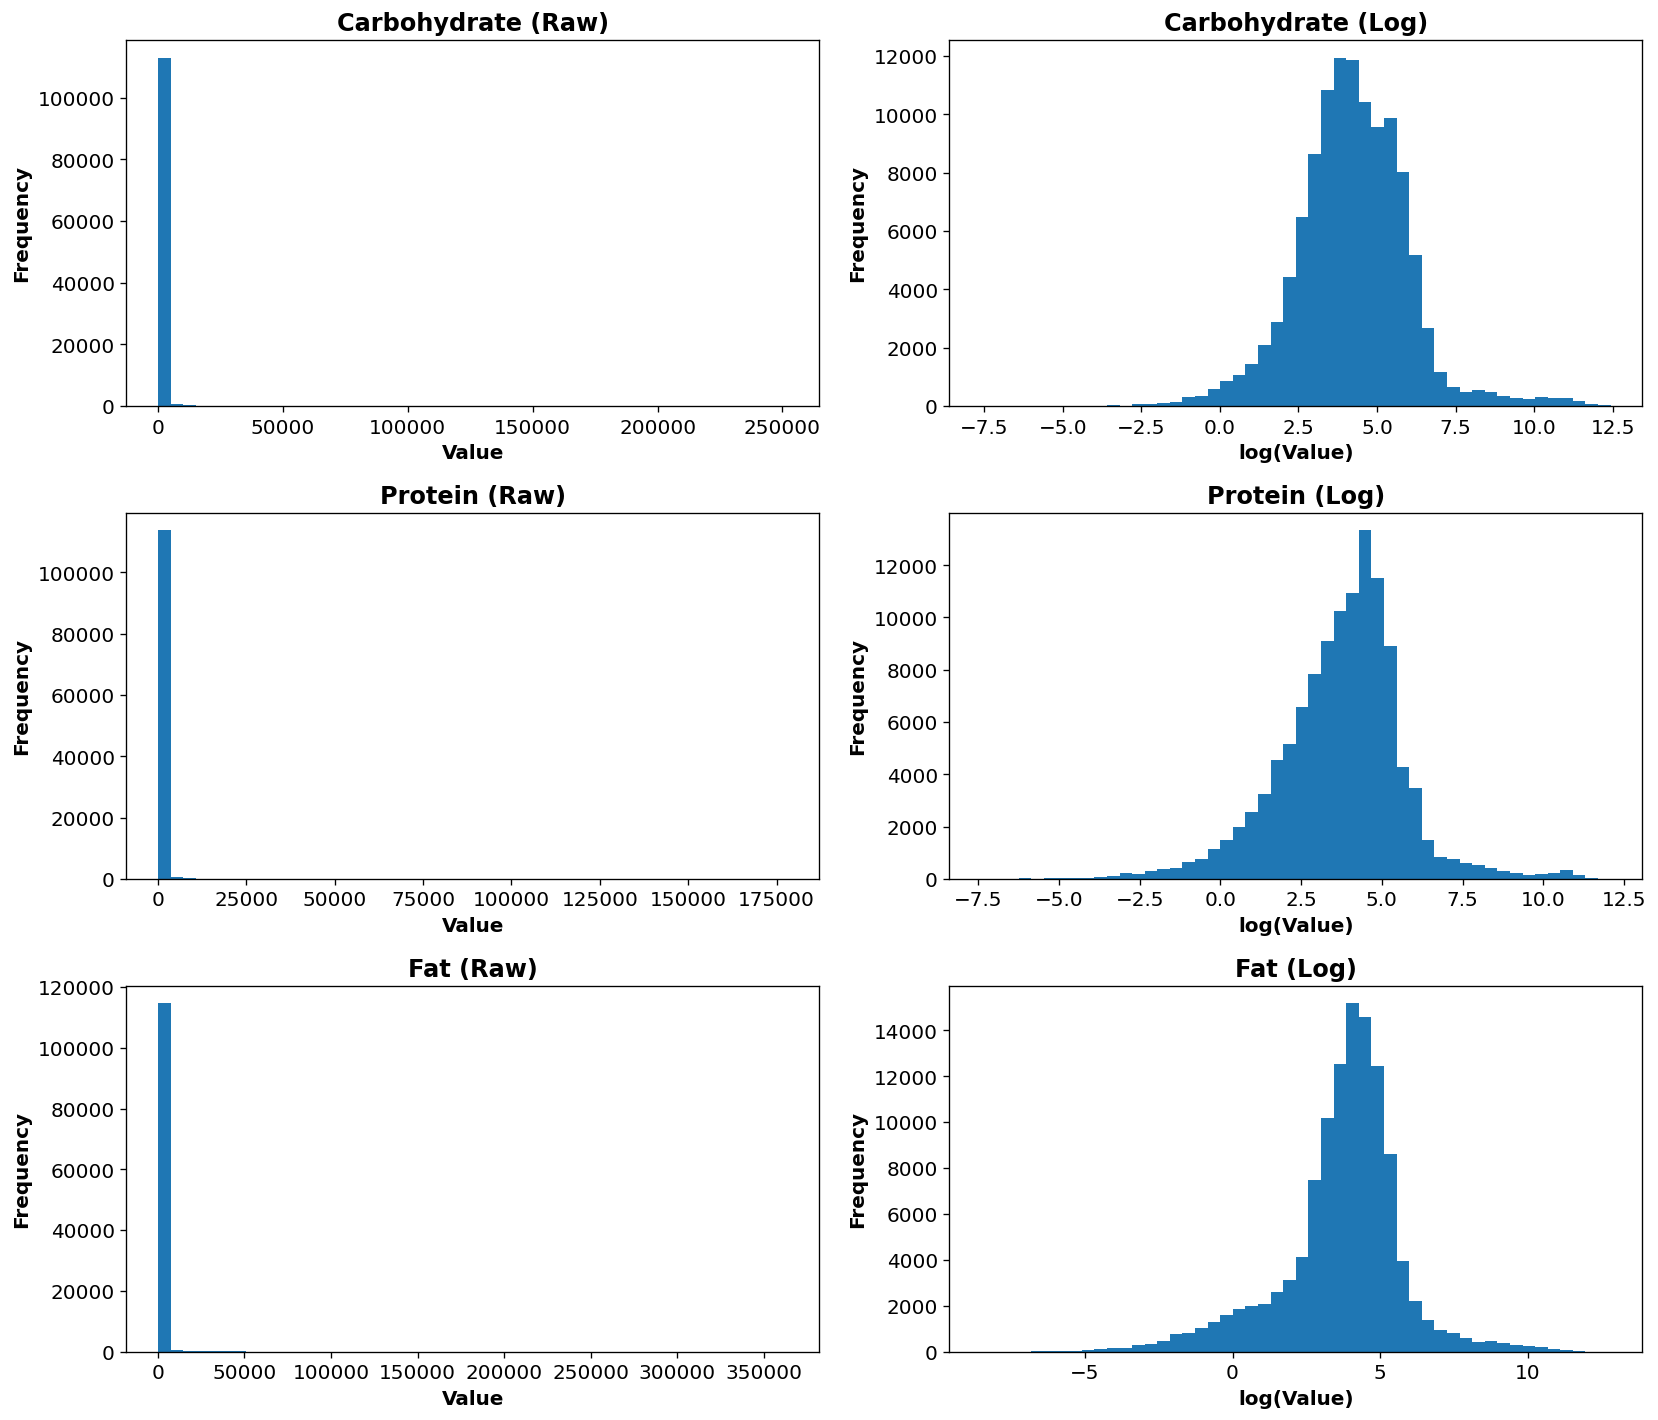

In [159]:
# ============================================================
# Cell 4: Raw vs Log Nutrient Distributions
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12)
)

for i, nutrient in enumerate(NUTRIENT_COLS):

    values = nutrient_df[nutrient]
    positive_values = values[values > 0]

    # -------------------------
    # Raw distribution
    # -------------------------
    axes[i, 0].hist(
        positive_values,
        bins=50
    )

    axes[i, 0].set_title(
        f"{NUTRIENT_SHORT[nutrient]} (Raw)"
    )

    axes[i, 0].set_xlabel("Value")
    axes[i, 0].set_ylabel("Frequency")

    # -------------------------
    # Log distribution
    # -------------------------
    log_values = np.log(positive_values)

    axes[i, 1].hist(
        log_values,
        bins=50
    )

    axes[i, 1].set_title(
        f"{NUTRIENT_SHORT[nutrient]} (Log)"
    )

    axes[i, 1].set_xlabel("log(Value)")
    axes[i, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Cell 4: Raw vs Log Nutrient Distributions

This cell compares the distributions of carbohydrate, protein, and fat before and after applying a logarithmic transformation.

### Key Observations

- Raw nutrient distributions are highly right-skewed, with a few recipes containing extremely large nutrient values.
- Taking the logarithm compresses these extreme values and produces distributions that are much closer to a symmetric bell shape.
- This suggests that nutrient concentrations may follow a **lognormal distribution**, motivating the use of log-space statistics in later analyses.

### Purpose

To justify analyzing nutrients in log-space rather than raw space.

In [160]:
# ============================================================
# Cell 5a: Investigate Extreme Nutrient Values
# ============================================================

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]

    print("\n" + "="*60)
    print(NUTRIENT_SHORT[nutrient])
    print("="*60)

    print(f"Maximum value : {values.max():,.2f}")
    print(f"95th percentile   : {values.quantile(0.95):,.2f}")
    print(f"99th percentile   : {values.quantile(0.99):,.2f}")
    print(f"99.5th percentile : {values.quantile(0.995):,.2f}")

    print("\nTop 10 largest values:")
    print(values.nlargest(10).to_list())



Carbohydrate
Maximum value : 252,062.68
95th percentile   : 819.61
99th percentile   : 20,179.47
99.5th percentile : 47,670.23

Top 10 largest values:
[252062.68, 241915.2, 241719.1529, 235037.2608, 222051.9192, 217882.3552, 207303.8265, 205171.0318, 201256.17, 191291.2601]

Protein
Maximum value : 178,134.37
95th percentile   : 551.46
99th percentile   : 8,981.00
99.5th percentile : 31,395.07

Top 10 largest values:
[178134.3738, 167162.197, 148417.6265, 119342.3548, 108087.1258, 108046.8904, 106749.9178, 105748.6865, 98344.2423, 94239.7287]

Fat
Maximum value : 363,846.98
95th percentile   : 625.24
99th percentile   : 9,276.63
99.5th percentile : 22,253.24

Top 10 largest values:
[363846.9756, 300570.3075, 254332.2912, 222710.5494, 218000.0, 214789.595, 160519.9559, 150286.1547, 150281.7839, 149432.3743]


In [161]:
# ============================================================
# Cell 5b: Nutrient Data Cleaning and Dataset Filtering
# ============================================================

# ------------------------------------------------------------
# Load original dataset
# ------------------------------------------------------------
print("Rows in df before filtering:", len(df))
full_df = df.copy()

# ------------------------------------------------------------
# Nutrient-specific cutoffs
# ------------------------------------------------------------

cutoffs = {}

cutoff_value=0.995

print("=" * 60)
print("CUTOFF USED : " ,cutoff_value*100)
print("=" * 60)
print()

print("=" * 60)
print("NUTRIENT DATA CLEANING")
print("=" * 60)

for nutrient in NUTRIENT_COLS:

    positive_values = full_df.loc[
        full_df[nutrient] > 0,
        nutrient
    ]

    cutoff = positive_values.quantile(cutoff_value)

    cutoffs[nutrient] = cutoff

    print(
        f"{NUTRIENT_SHORT[nutrient]:<15}"
        f" cutoff = {cutoff:,.2f}"
    )


# ------------------------------------------------------------
# Build removal mask
# ------------------------------------------------------------

remove_mask = pd.Series(
    False,
    index=full_df.index
)

for nutrient in NUTRIENT_COLS:

    # remove_mask |= (
    #     full_df[nutrient] <= 0
    # )

    remove_mask |= (
        full_df[nutrient] > cutoffs[nutrient]
    )

# ------------------------------------------------------------
# Split datasets
# ------------------------------------------------------------

removed_df = full_df[remove_mask].copy()


filtered_df = full_df[
    ~remove_mask
].copy()
# Match preprocessing output used elsewhere
filtered_df["cuisine"] = filtered_df["Region"]
# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("FILTERING SUMMARY")
print("=" * 60)

print(f"Rows before percentile filtering : {len(full_df):,}")
print(f"Removed rows  : {len(removed_df):,}")
print(f"Remaining rows: {len(filtered_df):,}")

print(
    f"Percent removed: "
    f"{100 * len(removed_df) / len(full_df):.2f}%"
)

# ------------------------------------------------------------
# Save datasets
# ------------------------------------------------------------

filtered_df.to_csv(
    "DATA/PROCESSED/RecipeDB_Cuisine_Filtered.csv",
    index=False,
    float_format="%.4f"
)

removed_df.to_csv(
    "DATA/PROCESSED/RecipeDB_Cuisine_Removed.csv",
    index=False,
    float_format="%.4f"
)

# ------------------------------------------------------------
# Replace notebook dataframes
# ------------------------------------------------------------

df = filtered_df.copy()

nutrient_df = df[NUTRIENT_COLS].copy()

# ------------------------------------------------------------
# Final message
# ------------------------------------------------------------

print("\nSaved:")
print("  DATA/PROCESSED/RecipeDB_Cuisine_Filtered.csv")
print("  DATA/PROCESSED/RecipeDB_Cuisine_Removed.csv")

print("\nUpdated notebook dataframes:")
print(f"  df shape         : {df.shape}")
print(f"  nutrient_df rows : {len(nutrient_df):,}")
print(f"  cuisines         : {df['cuisine'].nunique()}")

print("\nThe filtered dataset will be used for all subsequent analyses.")

Rows in df before filtering: 117039
CUTOFF USED :  99.5

NUTRIENT DATA CLEANING
Carbohydrate    cutoff = 48,644.39
Protein         cutoff = 31,428.04
Fat             cutoff = 22,526.81


FILTERING SUMMARY
Rows before percentile filtering : 117,039
Removed rows  : 1,449
Remaining rows: 115,590
Percent removed: 1.24%

Saved:
  DATA/PROCESSED/RecipeDB_Cuisine_Filtered.csv
  DATA/PROCESSED/RecipeDB_Cuisine_Removed.csv

Updated notebook dataframes:
  df shape         : (115590, 9)
  nutrient_df rows : 115,590
  cuisines         : 26

The filtered dataset will be used for all subsequent analyses.


In [162]:
# ============================================================
# Cell 5c: Finding best cutoff percentile
# ============================================================


print(f"Rows before filtering : {len(full_df):,}")
print(f"Rows after filtering  : {len(df):,}")

for nutrient in NUTRIENT_COLS:

    values = full_df.loc[
        full_df[nutrient] > 0,
        nutrient
    ]

    print("\n" + nutrient)

    print(f"Mean   : {values.mean():,.2f}")
    print(f"Median : {values.median():,.2f}")

    for p in [0.90, 0.95, 0.99, 0.995, 0.999,1]:
        print(
            f"{100*p:5.1f}% : "
            f"{values.quantile(p):,.2f}"
        )


Rows before filtering : 117,039
Rows after filtering  : 115,590

Carbohydrate, by difference (g)
Mean   : 848.57
Median : 66.08
 90.0% : 459.11
 95.0% : 832.96
 99.0% : 20,604.25
 99.5% : 48,644.39
 99.9% : 100,822.92
100.0% : 252,062.68

Protein (g)
Mean   : 515.35
Median : 50.71
 90.0% : 284.15
 95.0% : 561.17
 99.0% : 9,185.50
 99.5% : 31,428.04
 99.9% : 62,759.45
100.0% : 178,134.37

Total lipid (fat) (g)
Mean   : 492.84
Median : 55.07
 90.0% : 270.11
 95.0% : 635.38
 99.0% : 9,342.87
 99.5% : 22,526.81
 99.9% : 65,300.11
100.0% : 363,846.98


### Cell 5a: Investigation of Extreme Nutrient Values

Before statistical analysis, we inspect the nutrient distributions for unusually large values that may arise from annotation errors, unit inconsistencies, or other anomalies.

For each nutrient, we report:

* Maximum observed value
* 99th and 99.5th percentile values
* Largest observations in the dataset

These statistics help identify extreme observations and determine appropriate filtering thresholds for subsequent analyses.

### Cell 5b: Nutrient Data Filtering

Based on the inspection in Cell 5a, a filtered dataset is created by removing recipes with nutrient values exceeding a nutrient-specific percentile cutoff.

The filtering summary reports the cutoff values, the number of removed recipes, and the size of the resulting dataset. The filtered dataset is saved separately, and all subsequent analyses use this cleaned version.


### Cell 5c: Outlier Filtering and Dataset Preparation

Exploratory analysis of the nutrient distributions revealed the presence of extremely large nutrient values that were several orders of magnitude larger than the typical recipe values.

For example:

| Nutrient | Mean | Maximum |
|-----------|-----------:|-----------:|
| Carbohydrate | ~849 g | 252,063 g |
| Protein | ~515 g | 178,134 g |
| Fat | ~493 g | 363,847 g |

These maximum values are hundreds of times larger than the corresponding mean values and are likely attributable to annotation inconsistencies, unit-conversion issues, or other data-quality artifacts. Such observations can substantially influence distributional statistics and distort log-space analyses.

---

### Percentile-Based Threshold Analysis

To determine an appropriate filtering threshold, multiple percentile cutoffs were evaluated.

#### No Filtering

| Nutrient | Skew(log x) |
|-----------|-----------:|
| Carbohydrate | 0.2067 |
| Protein | -0.2635 |
| Fat | -0.6741 |

#### 99.5th Percentile Filtering

| Nutrient | Skew(log x) |
|-----------|-----------:|
| Carbohydrate | -0.1054 |
| Protein | -0.6431 |
| Fat | -0.9898 |

#### 99th Percentile Filtering

| Nutrient | Skew(log x) |
|-----------|-----------:|
| Carbohydrate | -0.3469 |
| Protein | -0.8178 |
| Fat | -1.1580 |

#### 95th Percentile Filtering

| Nutrient | Skew(log x) |
|-----------|-----------:|
| Carbohydrate | -0.7842 |
| Protein | -1.1454 |
| Fat | -1.5052 |

#### 90th Percentile Filtering

| Nutrient | Skew(log x) |
|-----------|-----------:|
| Carbohydrate | -0.9189 |
| Protein | -1.2004 |
| Fat | -1.5723 |

---

### Choice of the 99.5th Percentile Threshold

The 99.5th percentile threshold was selected because it provides a balance between:

1. Removing extreme nutrient values that are likely data-quality artifacts.
2. Preserving the overall shape of the nutrient distributions.
3. Minimizing distortion of log-space statistics.

More aggressive thresholds (99%, 95%, and 90%) produced increasingly negative log-skewness values, indicating that legitimate observations from the upper tail of the distribution were being removed. This substantially altered the distributional structure of the data.

In contrast, the 99.5th percentile threshold removed only the most extreme observations while maintaining distributional characteristics that remained closer to those observed in the original dataset.

---

### Treatment of Zero Values

Recipes containing zero values for a nutrient were retained in the dataset. Zero-valued observations may correspond to legitimate recipes that contain negligible amounts of a particular macronutrient (e.g., low-fat or low-carbohydrate recipes).

For analyses involving logarithmic transformations, zero values are excluded only for the nutrient currently being analyzed, since log(0) is undefined.

---

### Filtering Outcome

The original dataset contained **118,083** recipes.

After removing **1,044** recipes with missing nutrient values, **117,039** recipes remained for percentile-based filtering.

Applying nutrient-specific **99.5th percentile** thresholds removed an additional **1,449** recipes (**1.24%** of the cleaned dataset), resulting in a final dataset of **115,590** recipes.

Overall, **2,493** recipes (**2.11%** of the original dataset) were removed during preprocessing.

The resulting filtered dataset is used for all subsequent nutrient-distribution analyses.

In [163]:
# ============================================================
# Cell 6: Log-Space Statistics
# ============================================================

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    log_values = np.log(values)

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Mean(log x)": np.mean(log_values),
        "Std(log x)": np.std(log_values, ddof=1),
        "Skew(log x)": stats.skew(log_values, bias=False),
        "Median(log x)": np.median(log_values)
    })

log_stats_df = pd.DataFrame(records)

display(log_stats_df.round(4))

,Nutrient,Mean(log x),Std(log x),Skew(log x),Median(log x)
0,Carbohydrate,4.1666,1.6993,-0.1054,4.1751
1,Protein,3.6525,1.8351,-0.6431,3.9018
2,Fat,3.6447,1.9823,-0.9898,3.9942


### Cell 6: Log-Space Statistics

This cell computes summary statistics for the log-transformed nutrient values using the filtered dataset. Zero-valued observations are excluded prior to the logarithmic transformation since \(\log(0)\) is undefined.

### Key Observations

- The log-transformed distributions are substantially more symmetric than the raw nutrient distributions.
- Mean and median values are relatively close, indicating approximate symmetry in log-space.
- The similar log-space standard deviations across nutrients suggest comparable variability after transformation.

### Purpose

To summarize the location, spread, and symmetry of the log-transformed nutrient distributions before formal goodness-of-fit and normality analyses.

In [164]:
# ============================================================
# Cell 7: Normality Tests in Log Space
# ============================================================

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    log_values = np.log(values)

    # KS test against fitted Gaussian
    mu, sigma = norm.fit(log_values)

    D, p = kstest(
        log_values,
        'norm',
        args=(mu, sigma)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Mean(log x)": mu,
        "Std(log x)": sigma,
        "KS Distance": D,
        "p-value": p
    })

normality_df = pd.DataFrame(records)

display(normality_df.round(6))

,Nutrient,Mean(log x),Std(log x),KS Distance,p-value
0,Carbohydrate,4.166612,1.699274,0.033439,0.0
1,Protein,3.652498,1.835103,0.059171,0.0
2,Fat,3.644671,1.982279,0.116574,0.0


### Cell 7: Normality Tests in Log Space

This cell evaluates how closely the log-transformed nutrient values follow a Gaussian (normal) distribution using the Kolmogorov–Smirnov (KS) test.

### Key Observations

- All nutrients have relatively small KS distances, indicating that the log-transformed distributions are reasonably close to a Gaussian distribution.
- Carbohydrate shows the closest agreement with normality, while fat exhibits the largest deviation.
- Although all p-values are effectively zero, this is expected for a dataset of this size. Consequently, the KS distance provides a more informative measure of goodness-of-fit than the p-value.

### Purpose

To assess the extent to which the log-transformed nutrient distributions resemble a Gaussian distribution, thereby evaluating the suitability of a lognormal model for the original nutrient values.

,"Carbohydrate, by difference (g)",Protein (g),Total lipid (fat) (g)
"Carbohydrate, by difference (g)",1.000,0.387,0.350
Protein (g),0.387,1.000,0.585
Total lipid (fat) (g),0.350,0.585,1.000


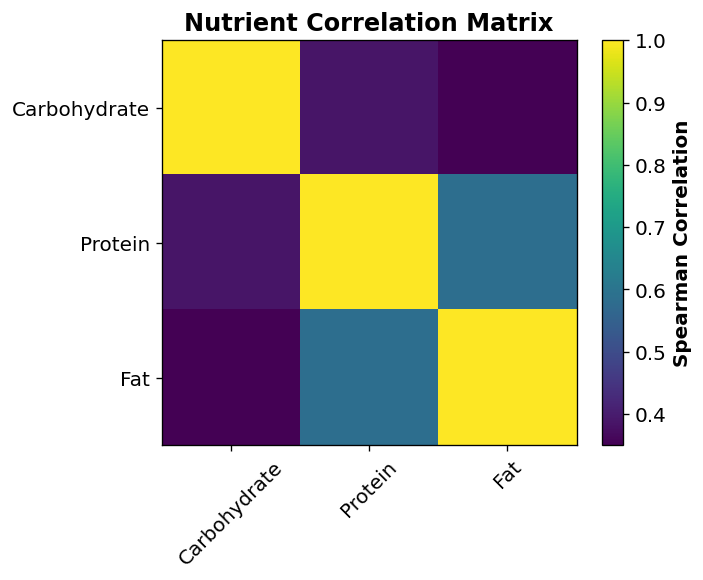

In [165]:
# ============================================================
# Cell 8: Nutrient Correlation Matrix
# ============================================================

corr_matrix = nutrient_df[NUTRIENT_COLS].corr(method="spearman")

display(corr_matrix.round(3))

plt.figure(figsize=(6,5))

plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Spearman Correlation")

plt.xticks(
    range(len(NUTRIENT_COLS)),
    [NUTRIENT_SHORT[n] for n in NUTRIENT_COLS],
    rotation=45
)

plt.yticks(
    range(len(NUTRIENT_COLS)),
    [NUTRIENT_SHORT[n] for n in NUTRIENT_COLS]
)

plt.title("Nutrient Correlation Matrix")
plt.tight_layout()
plt.show()

### Cell 8: Nutrient Correlation Analysis

This cell examines the relationships between carbohydrate, protein, and fat using the Spearman rank correlation coefficient.

### Key Observations

- All nutrient pairs exhibit positive correlations, indicating that recipes high in one macronutrient generally also tend to be high in the others.
- Protein and fat show the strongest positive association (Spearman's ρ = 0.585), suggesting that protein-rich recipes generally also tend to be fat-rich.
- Carbohydrate has moderate positive associations with protein (ρ = 0.387) and fat (ρ = 0.350).
- The correlation coefficients indicate the **strength and direction** of the monotonic relationships between nutrients; they do **not** represent the percentage of correlation or the proportion of one nutrient explained by another.

### Purpose

To quantify the associations between macronutrients and assess how nutrient levels co-vary across recipes.

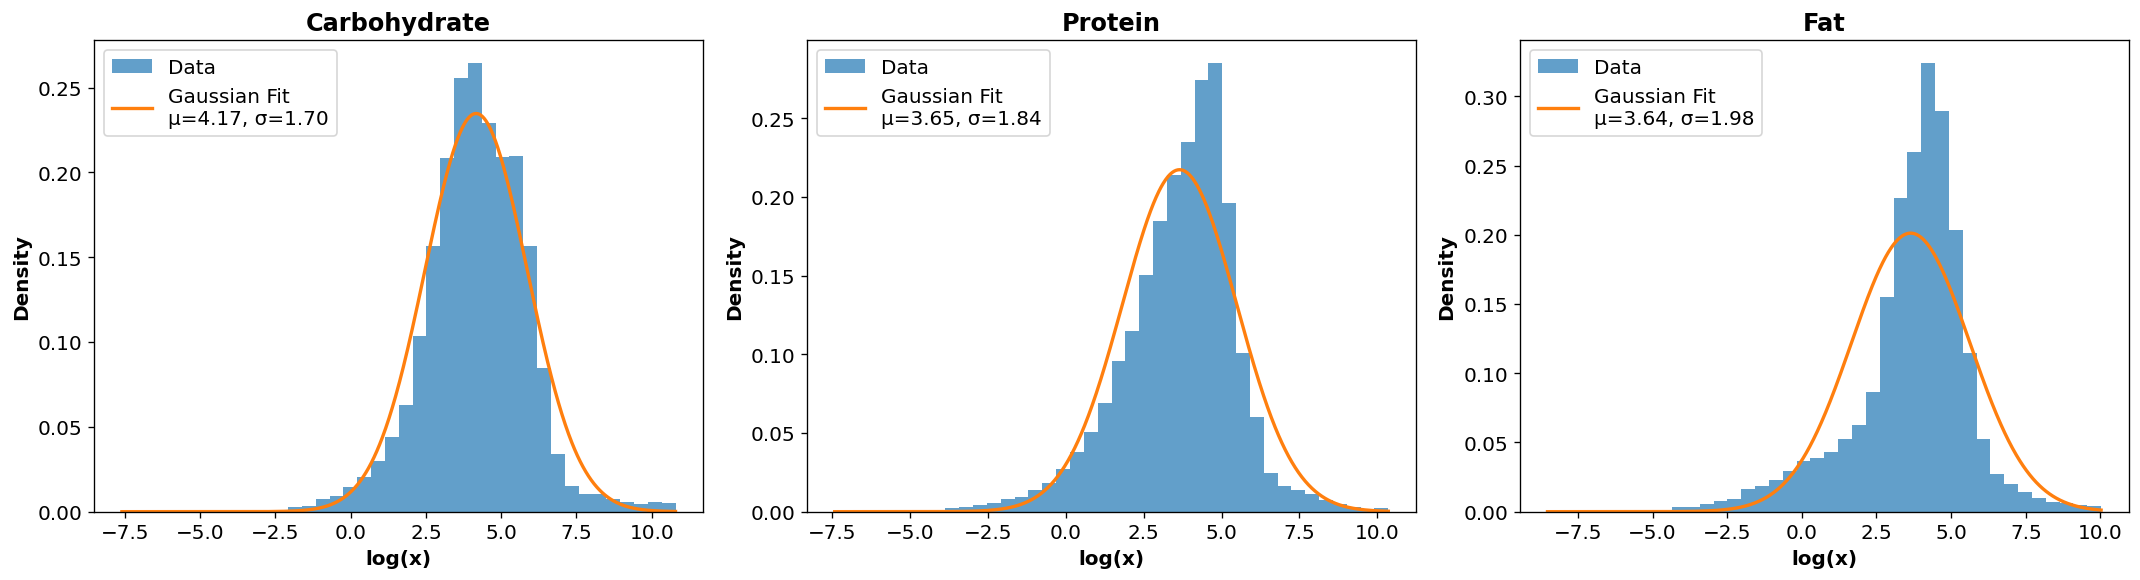

In [166]:
# ============================================================
# Cell 9: Nutrient Distributions Q(x_n)
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, nutrient in zip(axes, NUTRIENT_COLS):

    values = nutrient_df[nutrient]
    values = values[values > 0]

    # Histogram in log-space
    log_values = np.log(values)

    ax.hist(
        log_values,
        bins=40,
        density=True,
        alpha=0.7,
        label="Data"
    )

    # Gaussian fit
    mu, sigma = norm.fit(log_values)

    x = np.linspace(
        log_values.min(),
        log_values.max(),
        1000
    )

    ax.plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2,
        label=f"Gaussian Fit\nμ={mu:.2f}, σ={sigma:.2f}"
    )

    ax.set_title(NUTRIENT_SHORT[nutrient])
    ax.set_xlabel("log(x)")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

### Cell 9: Log-Space Nutrient Distributions

This cell visualizes the log-transformed nutrient distributions and compares them with their corresponding fitted Gaussian distributions.

### Key Observations

- The fitted Gaussian curves provide a reasonable approximation to the observed log-transformed nutrient distributions.
- Carbohydrate exhibits the closest agreement with the Gaussian fit.
- Protein and fat show progressively larger deviations, particularly in the tails, with fat displaying the greatest departure.
- Overall, the distributions exhibit approximately Gaussian behavior in log-space despite modest deviations from perfect normality.

### Purpose

To visually assess the suitability of a Gaussian model for the log-transformed nutrient distributions, complementing the quantitative goodness-of-fit results obtained from the KS test in Cell 7.

,Nutrient,Mean Concentration (μₙ),Log Std (sₙ)
0,Carbohydrate,402.876639,1.699282
1,Protein,196.133286,1.835111
2,Fat,209.892314,1.982288


Mean sₙ = 1.8389
Std  sₙ = 0.1415
coefficient of variation (CV) = 7.70%
Maximum deviation from mean = 7.80%


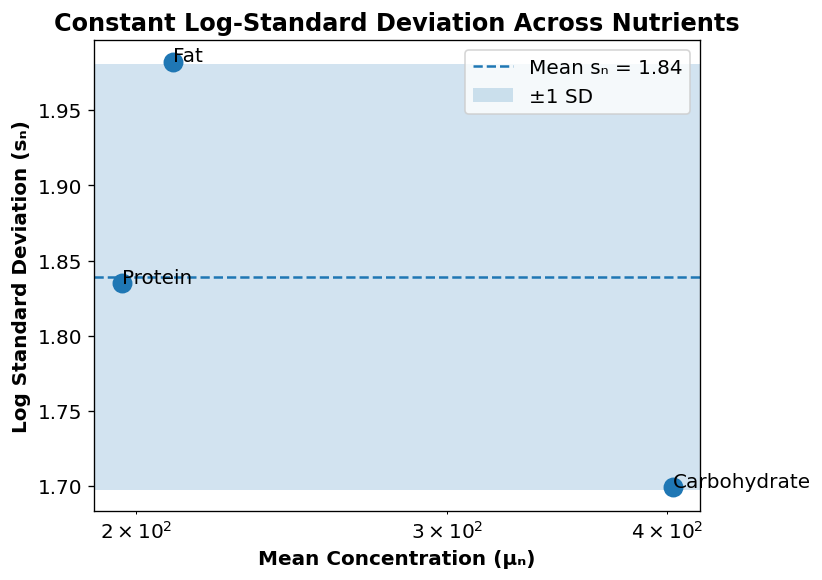

In [167]:
# ============================================================
# Cell 10: Constant Log-Standard Deviation (Fig 3a)
# ============================================================

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    mu_n = np.mean(values)

    log_values = np.log(values)
    s_n = np.std(log_values, ddof=1)

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Mean Concentration (μₙ)": mu_n,
        "Log Std (sₙ)": s_n
    })

fig3a_df = pd.DataFrame(records)

display(fig3a_df)

# ------------------------------------------------------------
# Summary Statistics
# ------------------------------------------------------------

mean_s = fig3a_df["Log Std (sₙ)"].mean()
std_s = fig3a_df["Log Std (sₙ)"].std(ddof=1)

print(f"Mean sₙ = {mean_s:.4f}")
print(f"Std  sₙ = {std_s:.4f}")
print(f"coefficient of variation (CV) = {100*std_s/mean_s:.2f}%")
max_dev = (
    np.abs(fig3a_df["Log Std (sₙ)"] - mean_s)
    / mean_s
).max()

print(f"Maximum deviation from mean = {100*max_dev:.2f}%")

# ------------------------------------------------------------
# Plot (Paper Fig 3a)
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

plt.scatter(
    fig3a_df["Mean Concentration (μₙ)"],
    fig3a_df["Log Std (sₙ)"],
    s=120
)

for _, row in fig3a_df.iterrows():
    plt.annotate(
        row["Nutrient"],
        (
            row["Mean Concentration (μₙ)"],
            row["Log Std (sₙ)"]
        )
    )

# Mean line
plt.axhline(
    mean_s,
    linestyle="--",
    label=f"Mean sₙ = {mean_s:.2f}"
)

# Mean ± Std band
plt.axhspan(
    mean_s - std_s,
    mean_s + std_s,
    alpha=0.2,
    label="±1 SD"
)

plt.xscale("log")

plt.xlabel("Mean Concentration (μₙ)")
plt.ylabel("Log Standard Deviation (sₙ)")
plt.title("Constant Log-Standard Deviation Across Nutrients")

plt.legend()
plt.tight_layout()
plt.show()

### Cell 10: Constant Log-Standard Deviation Across Nutrients

This cell computes the log-space standard deviation (\(s_n\)) for each macronutrient using positive nutrient values from the filtered dataset and examines whether the spread of the log-transformed distributions is approximately constant across nutrients.

### Key Observations

- The log-space standard deviations range from **1.70** to **1.98**, with a mean of **1.84**.
- The coefficient of variation is **7.70%**, indicating relatively small variation in \(s_n\) across nutrients.
- All three nutrients lie within one standard deviation of the mean \(s_n\), supporting the assumption of an approximately constant log-space spread.

### Purpose

To evaluate whether the log-transformed nutrient distributions exhibit an approximately constant standard deviation across nutrients, reproducing the analysis presented in Fig. 3a.

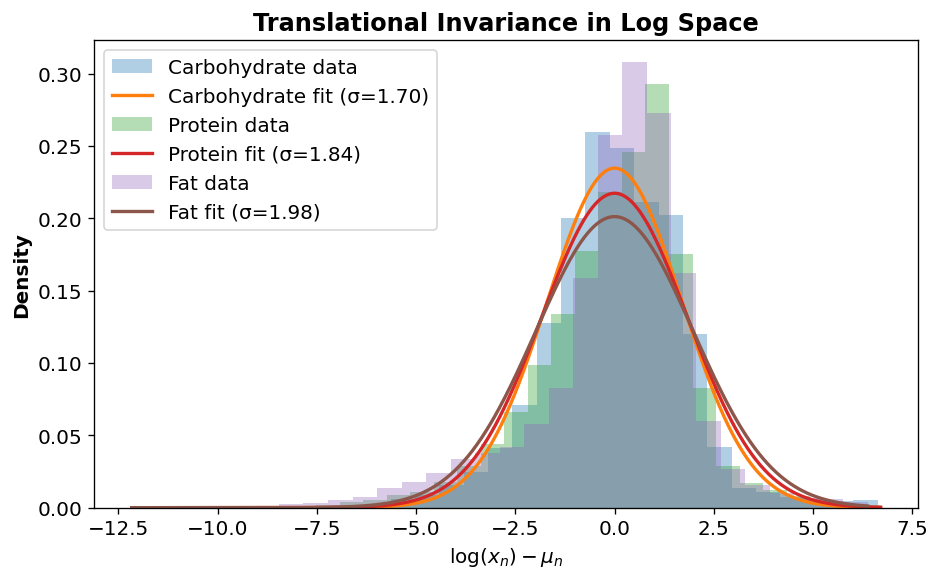


Centered Distribution Widths


,Nutrient,Sigma (Centered)
0,Carbohydrate,1.699274
1,Protein,1.835103
2,Fat,1.982279



Mean σ = 1.8389
Std  σ = 0.1415
CV     = 7.70%

Pairwise KS Tests


,Nutrient 1,Nutrient 2,KS Statistic (D),P-value
0,Carbohydrate,Protein,0.0616,1.2613e-188
1,Carbohydrate,Fat,0.0936,0.0000e+00
2,Protein,Fat,0.0532,4.4887e-141


In [168]:
# ============================================================
# Cell 11: Translational Invariance in Log Space
# ============================================================

from scipy.stats import ks_2samp

rescaled_data = {}
sigma_values = []

fig, ax = plt.subplots(figsize=(8, 5))

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    log_values = np.log(values)

    # Center distribution
    centered = log_values - np.mean(log_values)

    rescaled_data[nutrient] = centered

    mu, sigma = norm.fit(centered)

    sigma_values.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Sigma (Centered)": sigma
    })

    x_grid = np.linspace(centered.min(), centered.max(), 500)

    ax.hist(
        centered,
        bins=30,
        density=True,
        alpha=0.35,
        label=f"{NUTRIENT_SHORT[nutrient]} data"
    )

    ax.plot(
        x_grid,
        norm.pdf(x_grid, mu, sigma),
        linewidth=2,
        label=f"{NUTRIENT_SHORT[nutrient]} fit (σ={sigma:.2f})"
    )

ax.set_title("Translational Invariance in Log Space")
ax.set_xlabel(r"$\log(x_n)-\mu_n$")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Distribution Width Statistics
# ------------------------------------------------------------

sigma_df = pd.DataFrame(sigma_values)

print("\nCentered Distribution Widths")
display(sigma_df)

mean_sigma = sigma_df["Sigma (Centered)"].mean()
std_sigma = sigma_df["Sigma (Centered)"].std(ddof=1)
cv_sigma = 100 * std_sigma / mean_sigma

print(f"\nMean σ = {mean_sigma:.4f}")
print(f"Std  σ = {std_sigma:.4f}")
print(f"CV     = {cv_sigma:.2f}%")

# ------------------------------------------------------------
# Pairwise KS Tests
# ------------------------------------------------------------

# ------------------------------------------------------------
# Pairwise KS Tests
# ------------------------------------------------------------

ks_records = []

for i in range(len(NUTRIENT_COLS)):
    for j in range(i + 1, len(NUTRIENT_COLS)):

        nutrient_1 = NUTRIENT_COLS[i]
        nutrient_2 = NUTRIENT_COLS[j]

        D, p = ks_2samp(
            rescaled_data[nutrient_1],
            rescaled_data[nutrient_2]
        )

        ks_records.append({
            "Nutrient 1": NUTRIENT_SHORT[nutrient_1],
            "Nutrient 2": NUTRIENT_SHORT[nutrient_2],
            "KS Statistic (D)": round(D, 4),
            "P-value": f"{p:.4e}"
        })

ks_df = pd.DataFrame(ks_records)

print("\nPairwise KS Tests")
display(ks_df)

### Cell 11: Translational Invariance in Log Space

This cell examines whether the log-transformed nutrient distributions collapse onto a common shape after centering each distribution by its mean log value.

### Key Observations

- After centering, the three nutrient distributions exhibit similar overall shapes despite differences in their mean concentrations.
- The fitted Gaussian widths remain relatively similar across nutrients (mean σ = **1.84**, CV = **7.70%**), supporting an approximately constant log-space spread.
- Pairwise KS statistics are small (D = 0.053–0.094), indicating only modest differences between the centered distributions, although the large sample size results in statistically significant p-values.

### Purpose

To evaluate the translational invariance of nutrient distributions in log-space by comparing their centered distributions, reproducing the analysis presented in Fig. 3b.

,Nutrient,Mean(log x),Skew(log x)
0,Carbohydrate,4.1666,-0.1054
1,Protein,3.6525,-0.6431
2,Fat,3.6447,-0.9898


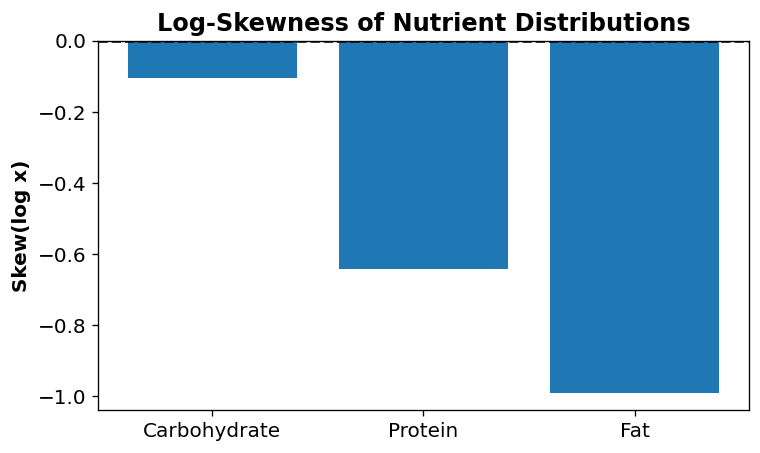

In [169]:
# ============================================================
# Cell 12: Log-Skewness Analysis
# ============================================================

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    log_values = np.log(values)

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Mean(log x)": np.mean(log_values),
        "Skew(log x)": stats.skew(log_values, bias=False)
    })

skew_df = pd.DataFrame(records)

display(skew_df.round(4))

plt.figure(figsize=(7,4))

plt.bar(
    skew_df["Nutrient"],
    skew_df["Skew(log x)"]
)

plt.axhline(
    0,
    linestyle="--",
    color="black"
)

plt.ylabel("Skew(log x)")
plt.title("Log-Skewness of Nutrient Distributions")

plt.show()

### Cell 12: Log-Skewness Analysis

This cell quantifies the asymmetry of the log-transformed nutrient distributions using the skewness coefficient.

### Key Observations

- All three nutrients exhibit negative log-skewness, indicating slightly longer left tails after log transformation.
- Carbohydrate is closest to symmetry (skew = −0.105), while protein (−0.643) and fat (−0.990) show progressively greater negative skewness.
- Despite these deviations, the log-transformed distributions are substantially more symmetric than the corresponding raw nutrient distributions.

### Purpose

To quantify the symmetry of the log-transformed nutrient distributions and assess the extent to which they approximate Gaussian behavior in log-space.

,Nutrient,Mean (μ),Std (σ)
0,Carbohydrate,402.8766,2436.6752
1,Protein,196.1333,1088.1631
2,Fat,209.8923,1044.4878


Slope (γ)      = 1.1919
Intercept      = 0.6423
R²             = 0.9836
P-value        = 0.081668
Std Error      = 0.1538


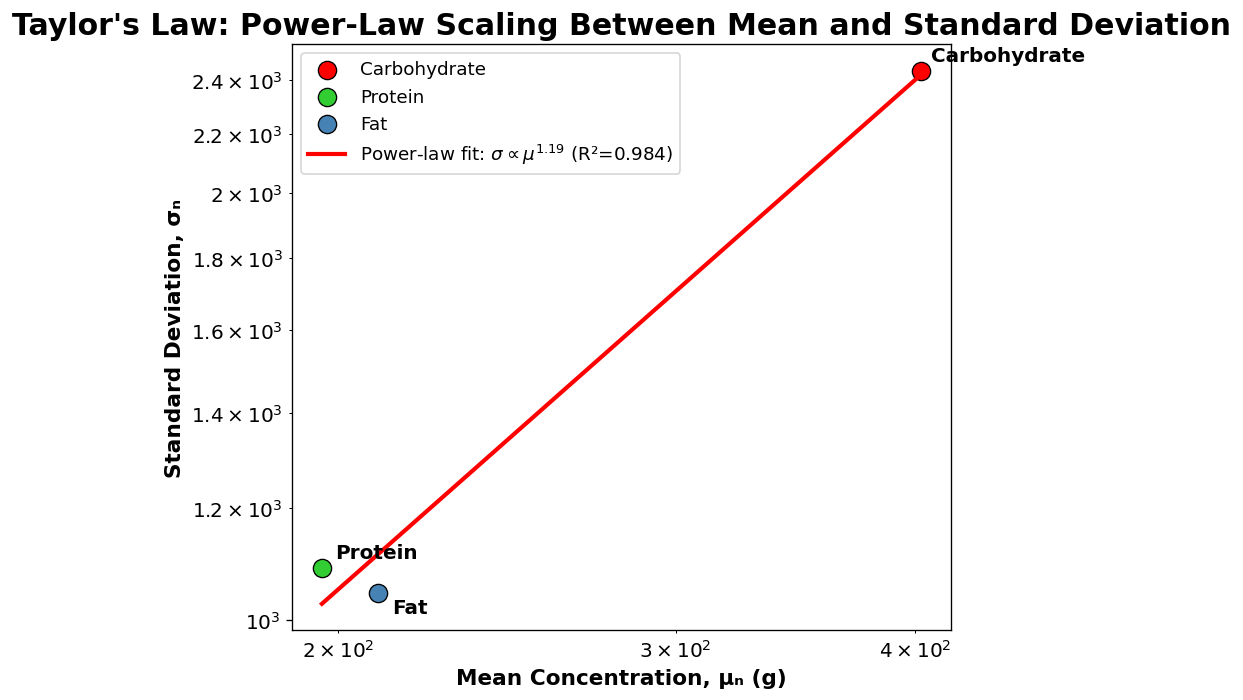

In [170]:
# ============================================================
# Cell 13: Power-Law Scaling of Standard Deviation and Mean
# ============================================================

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    mu = np.mean(values)
    sigma = np.std(values, ddof=1)

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Mean (μ)": mu,
        "Std (σ)": sigma
    })

powerlaw_df = pd.DataFrame(records)

display(powerlaw_df.round(4))

# ------------------------------------------------------------
# Log-Log Regression
# ------------------------------------------------------------

x = np.log(powerlaw_df["Mean (μ)"])
y = np.log(powerlaw_df["Std (σ)"])

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Slope (γ)      = {slope:.4f}")
print(f"Intercept      = {intercept:.4f}")
print(f"R²             = {r_value**2:.4f}")
print(f"P-value        = {p_value:.6f}")
print(f"Std Error      = {std_err:.4f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

# Colors similar to the paper
colors = {
    "Carbohydrate": "red",
    "Protein": "limegreen",
    "Fat": "steelblue"
}

# Scatter points
for _, row in powerlaw_df.iterrows():

    plt.scatter(
        row["Mean (μ)"],
        row["Std (σ)"],
        s=120,
        color=colors[row["Nutrient"]],
        edgecolor="black",
        linewidth=0.8,
        label=row["Nutrient"]
    )

# Power-law fit
x_fit = np.linspace(
    powerlaw_df["Mean (μ)"].min(),
    powerlaw_df["Mean (μ)"].max(),
    200
)

y_fit = np.exp(intercept) * x_fit**slope

plt.plot(
    x_fit,
    y_fit,
    color="red",
    linewidth=2.5,
    label=fr"Power-law fit: $\sigma \propto \mu^{{{slope:.2f}}}$"
          + f" (R²={r_value**2:.3f})"
)

# Better annotation positions
offsets = {
    "Carbohydrate": (6, 6),
    "Protein": (8, 6),
    "Fat": (8, -12)
}

for _, row in powerlaw_df.iterrows():

    dx, dy = offsets[row["Nutrient"]]

    plt.annotate(
        row["Nutrient"],
        (row["Mean (μ)"], row["Std (σ)"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold"
    )

# Log scales
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Mean Concentration, μₙ (g)", fontsize=13, fontweight="bold")
plt.ylabel("Standard Deviation, σₙ", fontsize=13, fontweight="bold")

plt.title(
    "Taylor's Law: Power-Law Scaling Between Mean and Standard Deviation",
    fontsize=18,
    fontweight="bold"
)

plt.legend(loc="upper left", fontsize=11)

plt.tight_layout()
plt.show()

### Cell 13: Mean–Variance Scaling Analysis

This cell examines whether the standard deviation of nutrient concentrations scales with the mean according to Taylor's law, \( \sigma \propto \mu^{\gamma} \). A linear regression is performed in log-log space using the mean and standard deviation of each macronutrient.

### Key Observations

- The log-log regression yields a scaling exponent of **γ = 1.19** with an **R² = 0.984**, indicating a strong linear relationship between the mean and standard deviation.
- The fitted exponent suggests that nutrient variability increases approximately as a power law with the mean.
- Although the regression has a high coefficient of determination, the **p-value (0.082)** is greater than the conventional significance threshold of **0.05**. This is primarily because the analysis is based on only **three macronutrients**, providing limited statistical power.
- Consequently, the observed scaling relationship should be interpreted as **exploratory**, despite its strong visual agreement with Taylor's law.

### Purpose

To evaluate whether nutrient variability follows Taylor's law by examining the power-law relationship between the mean and standard deviation.Regeneration of suplimmentry fig 5

The evidence for Taylor's Law is much weaker

In [171]:
# ============================================================
# Cell 14a: Distribution Comparison (KS + AIC + BIC)
# ============================================================

from scipy.stats import (
    lognorm,
    gamma,
    weibull_min,
    norm,
    expon,
    uniform,
    kstest
)

results = []

DISTRIBUTIONS = {
    "Lognormal": lognorm,
    "Gamma": gamma,
    "Weibull": weibull_min,
    "Gaussian": norm,
    "Exponential": expon,
    "Uniform": uniform
}

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    n = len(values)

    for name, dist in DISTRIBUTIONS.items():

        try:

            params = dist.fit(values)

            loglik = np.sum(dist.logpdf(values, *params))

            k = len(params)

            aic = 2 * k - 2 * loglik
            bic = k * np.log(n) - 2 * loglik

            D, p = kstest(
                values,
                dist.cdf,
                args=params
            )

            results.append({
                "Nutrient": NUTRIENT_SHORT[nutrient],
                "Distribution": name,
                "KS D": D,
                "KS p": p,
                "AIC": aic,
                "BIC": bic
            })

        except Exception:
            pass

comparison_df = pd.DataFrame(results)

display(comparison_df.round(4))

,Nutrient,Distribution,KS D,KS p,AIC,BIC
0,Carbohydrate,Lognormal,0.0279,0.0,1.391245e+06,1.391274e+06
1,Carbohydrate,Gamma,0.9975,0.0,2.420088e+07,2.420091e+07
2,Carbohydrate,Weibull,0.1751,0.0,1.428856e+06,1.428885e+06
3,Carbohydrate,Gaussian,0.4343,0.0,2.098936e+06,2.098955e+06
4,Carbohydrate,Exponential,0.3882,0.0,1.593704e+06,1.593723e+06
5,Carbohydrate,Uniform,0.9458,0.0,2.457391e+06,2.457411e+06
6,Protein,Lognormal,0.0457,0.0,1.294106e+06,1.294135e+06
7,Protein,Gamma,0.9962,0.0,1.311894e+07,1.311897e+07
8,Protein,Weibull,0.1033,0.0,1.308141e+06,1.308169e+06
9,Protein,Gaussian,0.4285,0.0,1.922144e+06,1.922163e+06


,Nutrient,Distribution,KS D
0,Carbohydrate,Lognormal,0.0334
1,Carbohydrate,Gamma,0.1878
2,Carbohydrate,Weibull,0.0915
3,Carbohydrate,Gaussian,0.4343
4,Carbohydrate,Exponential,0.3882
5,Carbohydrate,Uniform,0.9458
6,Protein,Lognormal,0.0592
7,Protein,Gamma,0.1578
8,Protein,Weibull,0.0746
9,Protein,Gaussian,0.4285



Best-Fitting Distribution for Each Macronutrient



,Nutrient,Distribution,KS D
0,Carbohydrate,Lognormal,0.033439
1,Fat,Weibull,0.085126
2,Protein,Lognormal,0.059171


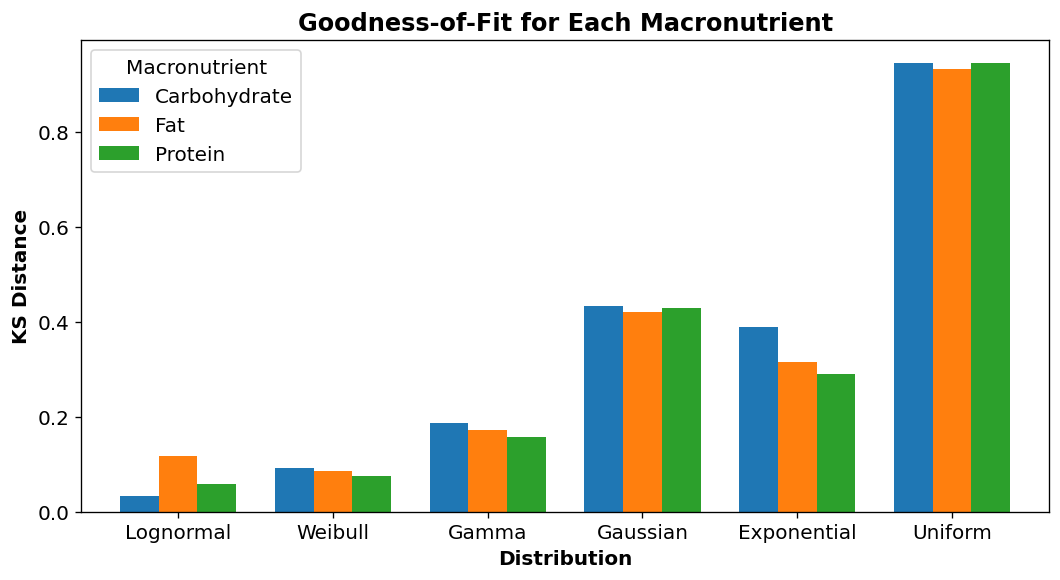

In [172]:
# ============================================================
# Cell 14B: Best-Fitting Distribution for Each Macronutrient
# ============================================================

from scipy.stats import (
    lognorm,
    gamma,
    weibull_min,
    norm,
    expon,
    uniform,
    kstest
)

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    # ---------------------------
    # Lognormal
    # ---------------------------
    shape, loc, scale = lognorm.fit(values, floc=0)

    D, _ = kstest(
        values,
        "lognorm",
        args=(shape, loc, scale)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Distribution": "Lognormal",
        "KS D": D
    })

    # ---------------------------
    # Gamma
    # ---------------------------
    a, loc, scale = gamma.fit(values, floc=0)

    D, _ = kstest(
        values,
        "gamma",
        args=(a, loc, scale)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Distribution": "Gamma",
        "KS D": D
    })

    # ---------------------------
    # Weibull
    # ---------------------------
    c, loc, scale = weibull_min.fit(values, floc=0)

    D, _ = kstest(
        values,
        "weibull_min",
        args=(c, loc, scale)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Distribution": "Weibull",
        "KS D": D
    })

    # ---------------------------
    # Gaussian
    # ---------------------------
    mu, sigma = norm.fit(values)

    D, _ = kstest(
        values,
        "norm",
        args=(mu, sigma)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Distribution": "Gaussian",
        "KS D": D
    })

    # ---------------------------
    # Exponential
    # ---------------------------
    loc, scale = expon.fit(values, floc=0)

    D, _ = kstest(
        values,
        "expon",
        args=(loc, scale)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Distribution": "Exponential",
        "KS D": D
    })

    # ---------------------------
    # Uniform
    # ---------------------------
    loc, scale = uniform.fit(values)

    D, _ = kstest(
        values,
        "uniform",
        args=(loc, scale)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Distribution": "Uniform",
        "KS D": D
    })

# ------------------------------------------------------------
# KS Distance Table
# ------------------------------------------------------------

ks_reproduction_df = pd.DataFrame(records)

display(ks_reproduction_df.round(4))

# ------------------------------------------------------------
# Best Distribution for Each Macronutrient
# ------------------------------------------------------------

best_fit_df = (
    ks_reproduction_df
    .loc[
        ks_reproduction_df.groupby("Nutrient")["KS D"].idxmin()
    ]
    .reset_index(drop=True)
)

print("\nBest-Fitting Distribution for Each Macronutrient\n")
display(best_fit_df)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plot_df = (
    ks_reproduction_df
    .pivot(
        index="Distribution",
        columns="Nutrient",
        values="KS D"
    )
)

plot_df = plot_df.loc[
    [
        "Lognormal",
        "Weibull",
        "Gamma",
        "Gaussian",
        "Exponential",
        "Uniform"
    ]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(9,5),
    width=0.75
)

ax.set_ylabel("KS Distance")
ax.set_xlabel("Distribution")
ax.set_title("Goodness-of-Fit for Each Macronutrient")

plt.xticks(rotation=0)
plt.legend(title="Macronutrient")

plt.tight_layout()
plt.show()

,Distribution,Mean KS Distance
0,Lognormal,0.0697
1,Weibull,0.0837
2,Gamma,0.1727
3,Exponential,0.3315
4,Gaussian,0.4277
5,Uniform,0.9417


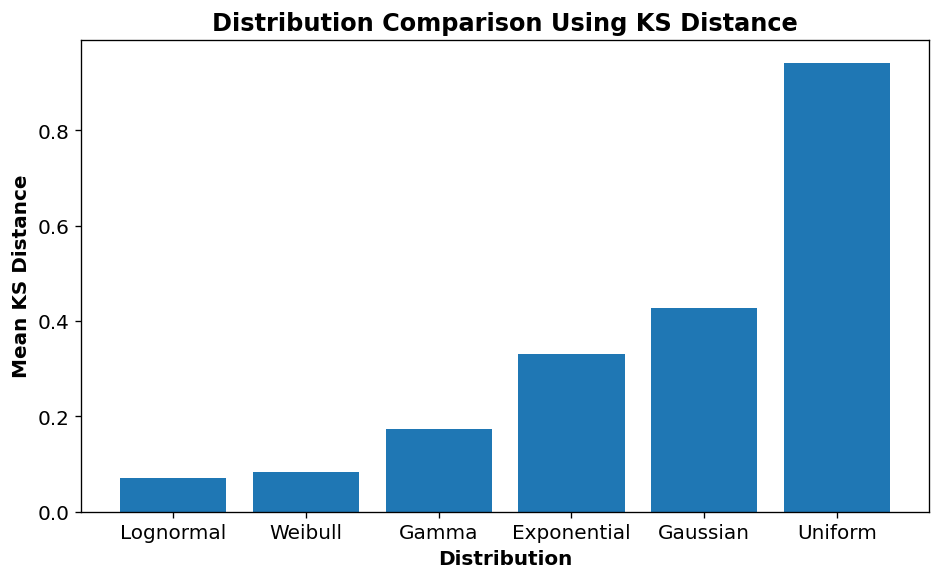

In [173]:
# ============================================================
# Cell 14C: Mean KS Distance by Distribution
# ============================================================

summary_df = (
    ks_reproduction_df
    .groupby("Distribution")["KS D"]
    .mean()
    .sort_values()
    .reset_index()
)

summary_df.columns = [
    "Distribution",
    "Mean KS Distance"
]

display(summary_df.round(4))


plt.figure(figsize=(8,5))

plt.bar(
    summary_df["Distribution"],
    summary_df["Mean KS Distance"]
)

plt.ylabel("Mean KS Distance")
plt.xlabel("Distribution")
plt.title("Distribution Comparison Using KS Distance")

plt.tight_layout()
plt.show()

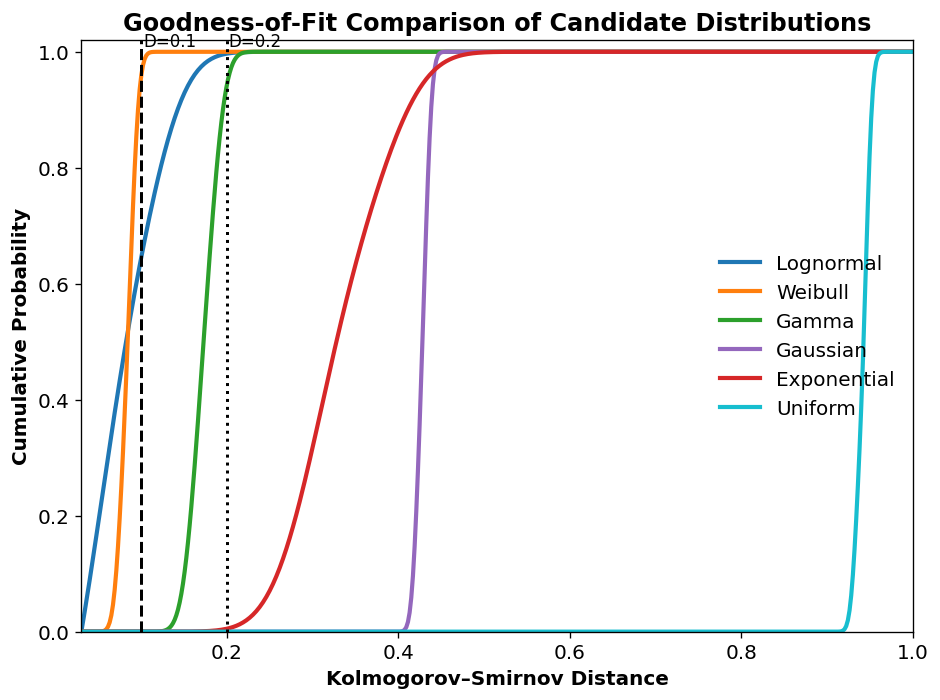

In [174]:
# ============================================================
# Cell 14D: Reproduction of Paper Fig. 3d
# ============================================================

from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Extract KS distances for each fitted distribution
# ------------------------------------------------------------

distribution_map = {
    "Lognormal": "Lognormal",
    "Weibull": "Weibull",
    "Gamma": "Gamma",
    "Gaussian": "Gaussian",
    "Exponential": "Exponential",
    "Uniform": "Uniform"
}

colors = {
    "Lognormal": "#1f77b4",
    "Weibull": "#ff7f0e",
    "Gamma": "#2ca02c",
    "Gaussian": "#9467bd",
    "Exponential": "#d62728",
    "Uniform": "#17becf"
}

# Minimum KS value across all distributions
all_d = ks_reproduction_df["KS D"].values
xmin = max(0, all_d.min()*0.9)

plt.figure(figsize=(8,6))

for dist in distribution_map:

    d_values = (
        ks_reproduction_df[
            ks_reproduction_df["Distribution"] == dist
        ]["KS D"]
        .values
    )

    # KDE
    kde = gaussian_kde(d_values, bw_method="scott")

    x = np.linspace(xmin, 1.0, 500)

    # Integrate KDE to obtain cumulative probability
    cdf = np.array([
        kde.integrate_box_1d(xmin, xi)
        for xi in x
    ])

    # Normalize
    cdf /= cdf[-1]

    plt.plot(
        x,
        cdf,
        lw=2.5,
        color=colors[dist],
        label=dist
    )

# ------------------------------------------------------------
# Reference thresholds
# ------------------------------------------------------------

plt.axvline(
    0.10,
    color="black",
    linestyle="--",
    linewidth=1.8
)

plt.axvline(
    0.20,
    color="black",
    linestyle=":",
    linewidth=1.8
)

plt.text(
    0.102,
    1.01,
    "D=0.1",
    fontsize=10
)

plt.text(
    0.202,
    1.01,
    "D=0.2",
    fontsize=10
)

plt.xlim(xmin,1)
plt.ylim(0,1.02)

plt.xlabel("Kolmogorov–Smirnov Distance")
plt.ylabel("Cumulative Probability")
plt.title("Goodness-of-Fit Comparison of Candidate Distributions")

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

### Cell 14A: Distribution Fitting and Model Comparison

This cell fits six candidate probability distributions—Lognormal, Gamma, Weibull, Gaussian, Exponential, and Uniform—to the nutrient data.

### Key Observations

- Goodness-of-fit is evaluated using the Kolmogorov–Smirnov (KS) statistic.
- Model quality is further assessed using the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC).
- These metrics provide complementary measures for comparing candidate probability distributions.

### Purpose

To quantitatively compare multiple probability distributions and evaluate their suitability for modeling macronutrient concentrations.

### Cell 14B: Best-Fitting Distribution for Each Macronutrient

This cell evaluates the goodness-of-fit of six candidate probability distributions—Lognormal, Gamma, Weibull, Gaussian, Exponential, and Uniform—for each macronutrient using the Kolmogorov–Smirnov (KS) statistic.

### Key Observations

- The KS distance is computed for each candidate distribution and macronutrient.
- The distribution with the smallest KS distance is identified as the best-fitting model for each macronutrient.
- A grouped bar chart compares the KS distances across all candidate distributions, allowing direct comparison of their goodness-of-fit.

### Purpose

To identify the best-fitting probability distribution for each macronutrient and compare the performance of different candidate distributions using the KS statistic.

### Cell 14C: Mean KS Distance Comparison

This cell summarizes the goodness-of-fit of each candidate distribution by computing the mean KS distance across all three macronutrients.

### Key Observations

- The Lognormal distribution has the lowest mean KS distance, followed by Weibull and Gamma.
- Gaussian, Exponential, and Uniform distributions exhibit substantially larger KS distances, indicating poorer agreement with the observed data.
- The bar chart provides an intuitive comparison of the overall performance of the candidate distributions.

### Purpose

To compare the overall goodness-of-fit of the candidate probability distributions using the average KS distance across macronutrients.

### Cell 14D: Reproduction of Fig. 3d

This cell reproduces the cumulative Kolmogorov–Smirnov (KS) distance analysis presented in Fig. 3d of the original paper. The cumulative distributions of KS distances are compared for six candidate probability distributions.

### Key Observations

- The Lognormal distribution consistently exhibits the smallest KS distances, indicating the best agreement with the nutrient data.
- Weibull provides the second-best fit, followed by the Gamma distribution.
- Gaussian, Exponential, and Uniform distributions show progressively poorer agreement with the observed nutrient distributions.
- Minor differences from the published figure are expected because the present analysis is performed on the filtered nutrient dataset.

### Purpose

To reproduce the goodness-of-fit comparison presented in Fig. 3d and visually compare the cumulative KS distance distributions of the candidate probability models.

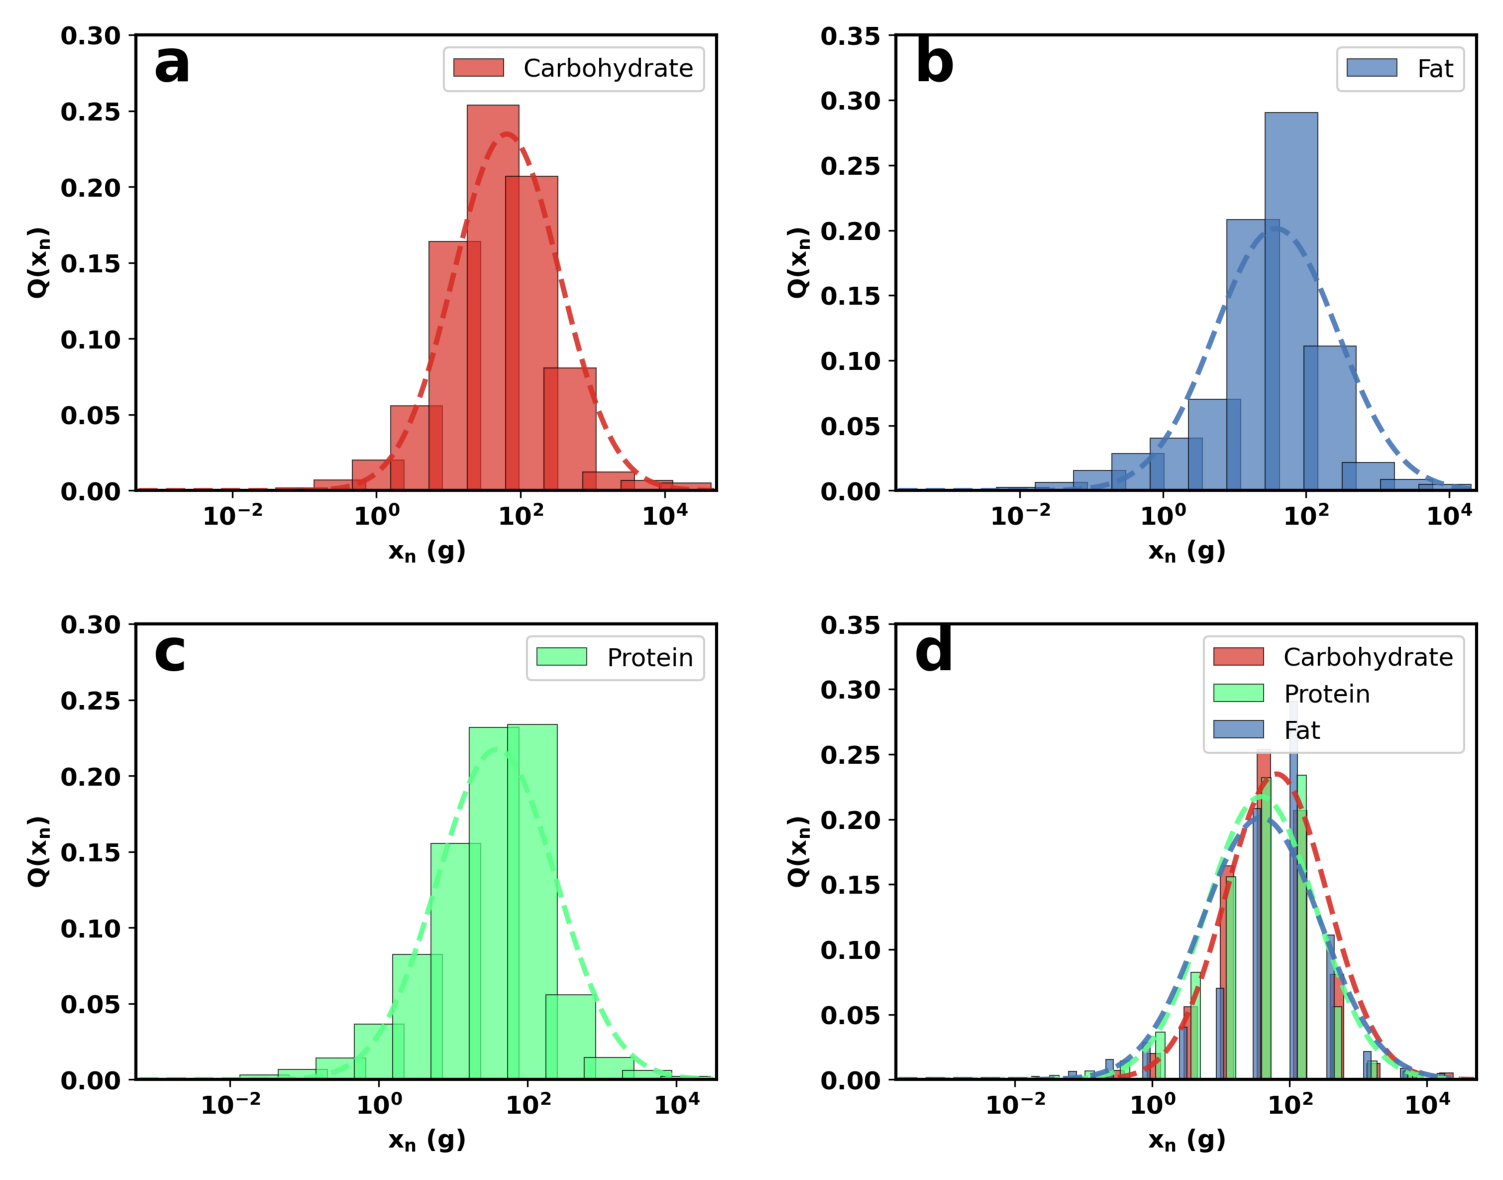

Extended Data Fig. 5 : Lognormal Fit Statistics


,Nutrient,Samples,Mean,Median,Std,Mean(log x),Std(log x),Skew(log x),Lognormal σ,KS D,KS p,AIC,BIC
0,Carbohydrate,113858,402.88,65.05,2436.68,4.1666,1.6993,-0.1054,1.6993,0.0334,0.0,1392661.0,1392690.0
1,Protein,114261,196.13,49.49,1088.16,3.6525,1.8351,-0.6431,1.8351,0.0592,0.0,1297677.0,1297706.0
2,Total lipid (fat),114637,209.89,54.28,1044.49,3.6447,1.9823,-0.9898,1.9823,0.1166,0.0,1317840.0,1317869.0


In [175]:
# ============================================================
# Cell 15: Regeneration of Extended Data Fig. 5
# ============================================================

from nutrient_matrix import NutrientMatrix
from nutrient_plotter import NutrientPlotter
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tempfile
import os

# ------------------------------------------------------------
# Use FILTERED dataframe
# ------------------------------------------------------------

paper_df = nutrient_df[
    [
        "Carbohydrate, by difference (g)",
        "Protein (g)",
        "Total lipid (fat) (g)"
    ]
].copy()

nm = NutrientMatrix(paper_df)
plotter = NutrientPlotter(nm)

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def generate_panel(nutrients_dict, letter):

    fig, ax = plotter.plot_Qxn(
        nutrients_dict,
        nbins=15,
        figsize=(5,4)
    )

    ax.text(
        0.03,
        0.90,
        letter,
        transform=ax.transAxes,
        fontsize=28,
        fontweight="bold"
    )

    tmp = tempfile.NamedTemporaryFile(
        suffix=".png",
        delete=False
    )

    fig.savefig(
        tmp.name,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    return tmp.name


# ------------------------------------------------------------
# Generate four panels exactly like paper
# ------------------------------------------------------------

panel_a = generate_panel(
    {
        "Carbohydrate, by difference (g)": {
            "label":"Carbohydrate",
            "color":"#d73027"
        }
    },
    "a"
)

panel_b = generate_panel(
    {
        "Total lipid (fat) (g)": {
            "label":"Fat",
            "color":"#4575b4"
        }
    },
    "b"
)

panel_c = generate_panel(
    {
        "Protein (g)": {
            "label":"Protein",
            "color":"#58ff87"
        }
    },
    "c"
)

panel_d = generate_panel(
    {
        "Carbohydrate, by difference (g)": {
            "label":"Carbohydrate",
            "color":"#d73027"
        },
        "Protein (g)": {
            "label":"Protein",
            "color":"#58ff87"
        },
        "Total lipid (fat) (g)": {
            "label":"Fat",
            "color":"#4575b4"
        }
    },
    "d"
)

# ------------------------------------------------------------
# Combine into 2×2 figure
# ------------------------------------------------------------

fig, axs = plt.subplots(
    2,
    2,
    figsize=(13,10)
)

for ax, img_path in zip(
    axs.flatten(),
    [panel_a, panel_b, panel_c, panel_d]
):

    img = mpimg.imread(img_path)

    ax.imshow(img)

    ax.axis("off")

plt.tight_layout()

plt.show()

# ============================================================
# Statistical Summary for Extended Data Fig. 5
# ============================================================

records = []

for nutrient in paper_df.columns:

    values = paper_df[nutrient]
    values = values[values > 0]

    n = len(values)

    # ----------------------------
    # Lognormal fit
    # ----------------------------
    shape, loc, scale = lognorm.fit(values, floc=0)

    # KS Test
    D, p = kstest(
        values,
        "lognorm",
        args=(shape, loc, scale)
    )

    # Log-likelihood
    loglik = np.sum(
        lognorm.logpdf(
            values,
            shape,
            loc,
            scale
        )
    )

    # Number of fitted parameters
    k = 3

    # Information Criteria
    AIC = 2*k - 2*loglik
    BIC = k*np.log(n) - 2*loglik

    log_values = np.log(values)

    records.append({

        "Nutrient":
            nutrient.replace(", by difference", "")
                    .replace(" (g)", ""),

        "Samples":
            n,

        "Mean":
            np.mean(values),

        "Median":
            np.median(values),

        "Std":
            np.std(values, ddof=1),

        "Mean(log x)":
            np.mean(log_values),

        "Std(log x)":
            np.std(log_values, ddof=1),

        "Skew(log x)":
            stats.skew(log_values, bias=False),

        "Lognormal σ":
            shape,

        "KS D":
            D,

        "KS p":
            p,

        "AIC":
            AIC,

        "BIC":
            BIC

    })

fig5_stats = pd.DataFrame(records)

print("="*80)
print("Extended Data Fig. 5 : Lognormal Fit Statistics")
print("="*80)

display(fig5_stats.round({
    "Mean":2,
    "Median":2,
    "Std":2,
    "Mean(log x)":4,
    "Std(log x)":4,
    "Skew(log x)":4,
    "Lognormal σ":4,
    "KS D":4,
    "KS p":6,
    "AIC":0,
    "BIC":0
}))
# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

for f in [panel_a, panel_b, panel_c, panel_d]:
    os.remove(f)

### Cell 15: Regeneration of Extended Data Fig. 5

This cell reproduces **Extended Data Fig. 5** from the original paper using the **filtered nutrient dataset**. Histograms of carbohydrate, fat, and protein concentrations are shown on a logarithmic scale together with their fitted lognormal distributions. Panel (d) overlays the three macronutrient distributions to examine whether they exhibit a common statistical form.

### Key Observations

- The regenerated histograms closely reproduce the overall shape reported in the original paper, with minor differences arising from the filtered dataset.
- All three macronutrients exhibit approximately lognormal distributions spanning several orders of magnitude.
- The fitted lognormal curves closely follow the empirical distributions, supporting the lognormal hypothesis.
- The overlay in panel (d) demonstrates that the three macronutrients have similar distributional shapes despite differences in their absolute concentrations.

### Additional Quantitative Analysis

In addition to reproducing the original figure, this work provides quantitative goodness-of-fit statistics that were not reported in the paper.

- Log-space summary statistics (mean, standard deviation, and skewness) were computed for each macronutrient.
- Kolmogorov–Smirnov (KS) statistics were used to evaluate the agreement between the empirical data and the fitted lognormal distributions.
- Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) values were calculated to provide an objective assessment of the fitted models.

These additional analyses complement the visual regeneration of Extended Data Fig. 5 and provide stronger quantitative evidence that macronutrient concentrations in the filtered recipe corpus are well described by lognormal distributions.

In [176]:
# ============================================================
# Cell 16: Cuisine-level Statistical Analysis
# Regeneration of Extended Data Fig. 6
# ============================================================

# Top 10 cuisines by recipe count
top_cuisines = df["cuisine"].value_counts().head(10).index.tolist()

print("Top 10 Cuisines:")
print(top_cuisines)

# ------------------------------------------------------------
# Compute cuisine-wise statistics
# ------------------------------------------------------------

records = []

for cuisine in top_cuisines:

    cuisine_data = df[df["cuisine"] == cuisine]

    for nutrient in NUTRIENT_COLS:

        values = cuisine_data[nutrient]
        values = values[values > 0]

        if len(values) < 30:
            continue

        log_values = np.log(values)

        records.append({
            "Cuisine": cuisine,
            "Nutrient": NUTRIENT_SHORT[nutrient],
            "Samples": len(values),
            "Mean": values.mean(),
            "Median": values.median(),
            "Std": values.std(ddof=1),
            "Mean(log x)": log_values.mean(),
            "Log Std (sₙ)": log_values.std(ddof=1),
            "Log Skew (skₙ)": stats.skew(log_values, bias=False)
        })

cuisine_stats_df = pd.DataFrame(records)

print("\nCuisine-level Statistics")
display(cuisine_stats_df.round(4))

# ------------------------------------------------------------
# Cuisine summary
# ------------------------------------------------------------

summary_df = (
    cuisine_stats_df
    .groupby("Cuisine", as_index=False)
    .agg({
        "Samples": "sum",
        "Log Std (sₙ)": "mean",
        "Log Skew (skₙ)": "mean"
    })
    .rename(columns={
        "Log Std (sₙ)": "Mean sₙ",
        "Log Skew (skₙ)": "Mean skₙ"
    })
    .sort_values("Samples", ascending=False)
)

print("\nCuisine Summary")
display(summary_df.round(4))

Top 10 Cuisines:
['Italian', 'Mexican', 'South American', 'Canadian', 'Indian Subcontinent', 'French', 'Chinese and Mongolian', 'Australian', 'US', 'UK']

Cuisine-level Statistics


,Cuisine,Nutrient,Samples,Mean,Median,Std,Mean(log x),Log Std (sₙ),Log Skew (skₙ)
0,Italian,Carbohydrate,16053,263.0815,50.1985,1732.4574,3.8777,1.6413,-0.2053
1,Italian,Protein,16171,181.7533,58.5623,931.7791,3.7651,1.7527,-0.8119
2,Italian,Fat,16232,172.7783,55.4858,874.1486,3.6845,1.8571,-1.1474
3,Mexican,Carbohydrate,14085,150.9649,56.2227,681.1020,3.9849,1.4806,-0.5166
4,Mexican,Protein,14109,110.4381,51.7783,424.8427,3.5100,1.8267,-0.8726
5,Mexican,Fat,14159,94.3196,41.0467,425.3867,3.1871,2.0346,-1.1172
6,South American,Carbohydrate,6919,177.7431,60.7887,921.6567,4.0481,1.4512,-0.5596
7,South American,Protein,6993,223.1025,110.8833,1223.8837,4.3410,1.5692,-1.2952
8,South American,Fat,7002,123.7803,56.8254,603.7522,3.7285,1.6025,-1.2530
9,Canadian,Carbohydrate,6526,203.5587,80.5320,806.2983,4.2448,1.6012,-0.6268



Cuisine Summary


,Cuisine,Samples,Mean sₙ,Mean skₙ
5,Italian,48456,1.7504,-0.7215
6,Mexican,42353,1.7806,-0.8355
7,South American,20914,1.5410,-1.0360
1,Canadian,19644,1.7538,-0.8485
4,Indian Subcontinent,18700,1.9430,-0.0585
3,French,18599,1.7836,-0.7570
2,Chinese and Mongolian,17311,1.6032,-0.6831
0,Australian,16338,2.3760,-0.2560
9,US,14714,1.6824,-1.1048
8,UK,12464,2.0025,-0.4680


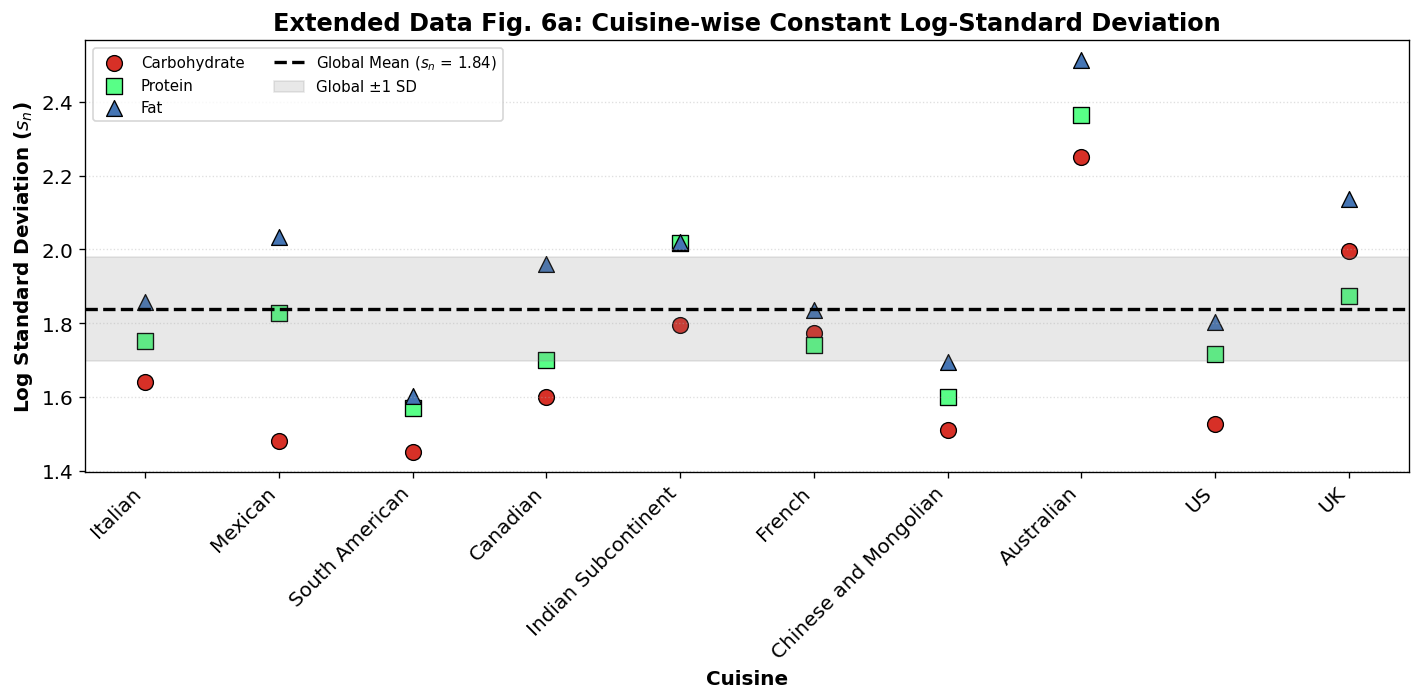


Cuisine-wise Deviation from Global Log Standard Deviation



,Cuisine,Nutrient,Log Std (sₙ),Deviation from Global
17,French,Fat,1.8361,0.0027
4,Mexican,Protein,1.8267,0.0122
2,Italian,Fat,1.8571,0.0183
26,US,Fat,1.8043,0.0346
28,UK,Protein,1.8738,0.0349
12,Indian Subcontinent,Carbohydrate,1.7940,0.0449
15,French,Carbohydrate,1.7736,0.0653
1,Italian,Protein,1.7527,0.0862
16,French,Protein,1.7411,0.0978
11,Canadian,Fat,1.9609,0.1220



Average Deviation by Cuisine



,Cuisine,Log Std (sₙ),Deviation from Global
3,French,1.7836,0.0553
5,Italian,1.7504,0.1007
4,Indian Subcontinent,1.9430,0.1340
9,US,1.6824,0.1565
8,UK,2.0025,0.1637
1,Canadian,1.7538,0.1664
6,Mexican,1.7806,0.1887
2,Chinese and Mongolian,1.6032,0.2357
7,South American,1.5410,0.2979
0,Australian,2.3760,0.5371


In [177]:
# ============================================================
# Cell 17: Extended Data Fig. 6a
# Cuisine-wise Constant Log-Standard Deviation
# ============================================================

plt.figure(figsize=(12, 6))

colors = {
    "Carbohydrate": "#d73027",
    "Protein": "#58ff87",
    "Fat": "#4575b4"
}

markers = {
    "Carbohydrate": "o",
    "Protein": "s",
    "Fat": "^"
}

x = np.arange(len(top_cuisines))

# ------------------------------------------------------------
# Plot each nutrient
# ------------------------------------------------------------

for nutrient in ["Carbohydrate", "Protein", "Fat"]:

    subset = (
        cuisine_stats_df[cuisine_stats_df["Nutrient"] == nutrient]
        .set_index("Cuisine")
        .loc[top_cuisines]
        .reset_index()
    )

    plt.scatter(
        x,
        subset["Log Std (sₙ)"],
        s=90,
        color=colors[nutrient],
        marker=markers[nutrient],
        edgecolor="black",
        linewidth=0.8,
        label=nutrient
    )

# ------------------------------------------------------------
# Global statistics from Cell 10
# ------------------------------------------------------------

plt.axhline(
    mean_s,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Global Mean ($s_n$ = {mean_s:.2f})"
)

plt.axhspan(
    mean_s - std_s,
    mean_s + std_s,
    color="gray",
    alpha=0.18,
    label="Global ±1 SD"
)

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.xticks(
    x,
    top_cuisines,
    rotation=45,
    ha="right"
)

plt.xlabel("Cuisine")
plt.ylabel(r"Log Standard Deviation ($s_n$)")
plt.title("Extended Data Fig. 6a: Cuisine-wise Constant Log-Standard Deviation")

plt.legend(
    ncol=2,
    fontsize=9
)

plt.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

deviation_df = cuisine_stats_df.copy()

deviation_df["Deviation from Global"] = (
    deviation_df["Log Std (sₙ)"] - mean_s
).abs()

deviation_df = deviation_df.sort_values(
    "Deviation from Global"
)

print("\nCuisine-wise Deviation from Global Log Standard Deviation\n")

display(
    deviation_df[
        [
            "Cuisine",
            "Nutrient",
            "Log Std (sₙ)",
            "Deviation from Global"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# Overall summary
# ------------------------------------------------------------

summary = (
    deviation_df
    .groupby("Cuisine", as_index=False)
    .agg({
        "Log Std (sₙ)": "mean",
        "Deviation from Global": "mean"
    })
    .sort_values("Deviation from Global")
)

print("\nAverage Deviation by Cuisine\n")

display(summary.round(4))

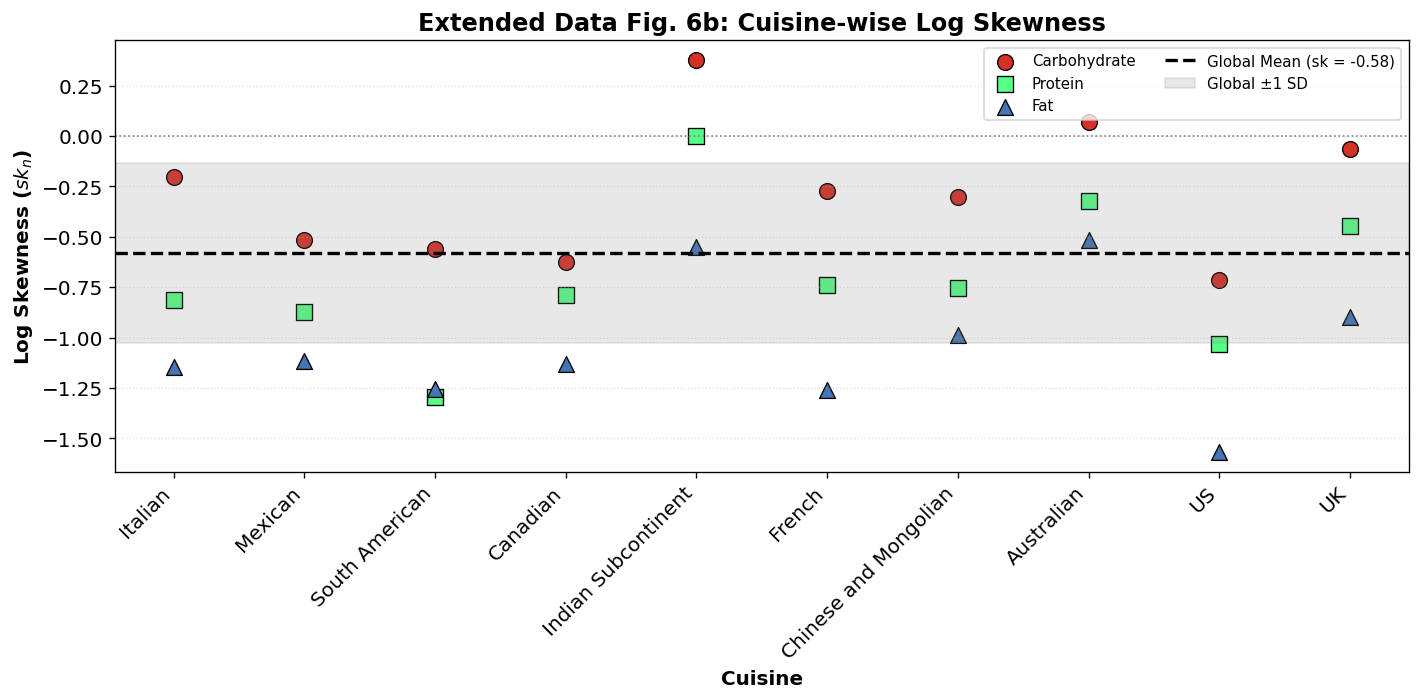


Cuisine-wise Deviation from Global Log Skewness



,Cuisine,Nutrient,Log Skew (skₙ),Deviation from Global
6,South American,Carbohydrate,-0.5596,0.0198
14,Indian Subcontinent,Fat,-0.5522,0.0273
9,Canadian,Carbohydrate,-0.6268,0.0474
23,Australian,Fat,-0.5172,0.0622
3,Mexican,Carbohydrate,-0.5166,0.0628
28,UK,Protein,-0.4453,0.1341
24,US,Carbohydrate,-0.7151,0.1356
16,French,Protein,-0.7416,0.1622
19,Chinese and Mongolian,Protein,-0.7566,0.1772
10,Canadian,Protein,-0.7876,0.2082



Average Deviation by Cuisine



,Cuisine,Log Skew (skₙ),Deviation from Global
1,Canadian,-0.8485,0.2690
2,Chinese and Mongolian,-0.6831,0.2868
6,Mexican,-0.8355,0.2979
8,UK,-0.4680,0.3224
0,Australian,-0.2560,0.3234
3,French,-0.7570,0.3828
5,Italian,-0.7215,0.3915
7,South American,-1.0360,0.4697
4,Indian Subcontinent,-0.0585,0.5210
9,US,-1.1048,0.5253


In [178]:
# ============================================================
# Cell 18: Extended Data Fig. 6b
# Cuisine-wise Log Skewness
# ============================================================

plt.figure(figsize=(12, 6))

colors = {
    "Carbohydrate": "#d73027",
    "Protein": "#58ff87",
    "Fat": "#4575b4"
}

markers = {
    "Carbohydrate": "o",
    "Protein": "s",
    "Fat": "^"
}

x = np.arange(len(top_cuisines))

# ------------------------------------------------------------
# Plot each nutrient
# ------------------------------------------------------------

for nutrient in ["Carbohydrate", "Protein", "Fat"]:

    subset = (
        cuisine_stats_df[cuisine_stats_df["Nutrient"] == nutrient]
        .set_index("Cuisine")
        .loc[top_cuisines]
        .reset_index()
    )

    plt.scatter(
        x,
        subset["Log Skew (skₙ)"],
        s=90,
        color=colors[nutrient],
        marker=markers[nutrient],
        edgecolor="black",
        linewidth=0.8,
        label=nutrient
    )

# ------------------------------------------------------------
# Global statistics (from Cell 11)
# ------------------------------------------------------------

global_skew = skew_df["Skew(log x)"].mean()
std_skew = skew_df["Skew(log x)"].std(ddof=1)

plt.axhline(
    global_skew,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Global Mean (sk = {global_skew:.2f})"
)

plt.axhspan(
    global_skew - std_skew,
    global_skew + std_skew,
    color="gray",
    alpha=0.18,
    label="Global ±1 SD"
)

plt.axhline(
    0,
    color="gray",
    linestyle=":",
    linewidth=1
)

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.xticks(
    x,
    top_cuisines,
    rotation=45,
    ha="right"
)

plt.xlabel("Cuisine")
plt.ylabel(r"Log Skewness ($sk_n$)")
plt.title("Extended Data Fig. 6b: Cuisine-wise Log Skewness")

plt.legend(
    ncol=2,
    fontsize=9
)

plt.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

deviation_df = cuisine_stats_df.copy()

deviation_df["Deviation from Global"] = (
    deviation_df["Log Skew (skₙ)"] - global_skew
).abs()

deviation_df = deviation_df.sort_values(
    "Deviation from Global"
)

print("\nCuisine-wise Deviation from Global Log Skewness\n")

display(
    deviation_df[
        [
            "Cuisine",
            "Nutrient",
            "Log Skew (skₙ)",
            "Deviation from Global"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# Overall summary
# ------------------------------------------------------------

summary = (
    deviation_df
    .groupby("Cuisine", as_index=False)
    .agg({
        "Log Skew (skₙ)": "mean",
        "Deviation from Global": "mean"
    })
    .sort_values("Deviation from Global")
)

print("\nAverage Deviation by Cuisine\n")

display(summary.round(4))

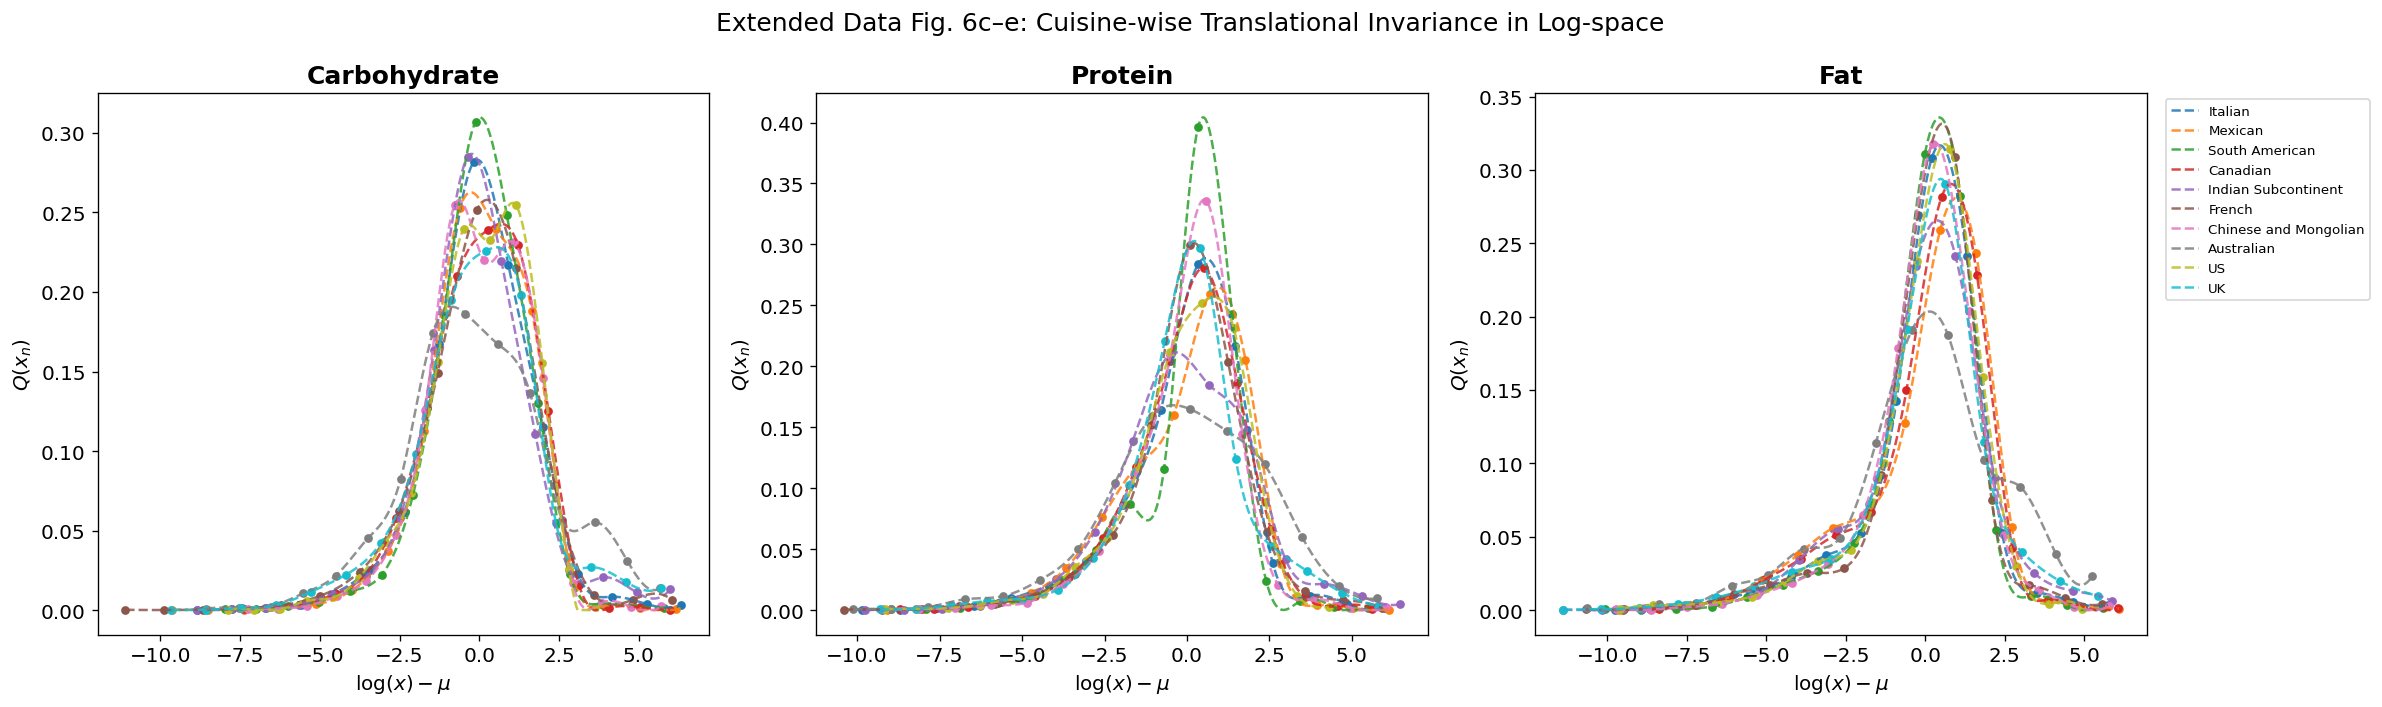


Cuisine-wise Translational Statistics



,Cuisine,Nutrient,Samples,Mean(log x),Log Std (sₙ),KS D,KS p
0,Italian,Carbohydrate,16053,3.8777,1.6413,0.0439,0.0000
1,Mexican,Carbohydrate,14085,3.9849,1.4806,0.0271,0.0000
2,South American,Carbohydrate,6919,4.0481,1.4512,0.0430,0.0000
3,Canadian,Carbohydrate,6526,4.2448,1.6012,0.0390,0.0000
4,Indian Subcontinent,Carbohydrate,6240,4.2653,1.7940,0.0581,0.0000
5,French,Carbohydrate,6169,4.1141,1.7736,0.0443,0.0000
6,Chinese and Mongolian,Carbohydrate,5759,4.2070,1.5120,0.0376,0.0000
7,Australian,Carbohydrate,5417,4.6275,2.2509,0.0257,0.0015
8,US,Carbohydrate,4901,4.2718,1.5271,0.0509,0.0000
9,UK,Carbohydrate,4132,4.5284,1.9961,0.0562,0.0000



Summary Statistics



,Mean Log Std,Std Log Std,Mean KS D,CV (%)
Nutrient,,,,
Carbohydrate,1.7028,0.2569,0.0426,15.0845
Fat,1.9462,0.2566,0.1089,13.1867
Protein,1.8160,0.2318,0.0770,12.7632


In [179]:
# ============================================================
# Cell 19: Extended Data Fig. 6c
# Regeneration of Extended Data Fig. 6c–e
# Cuisine-wise Translational Invariance
# ============================================================

from scipy.stats import kstest
from scipy.interpolate import make_interp_spline

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

records = []
colors = plt.cm.tab10(np.linspace(0, 1, len(top_cuisines)))

for ax, nutrient in zip(axes, NUTRIENT_COLS):

    for color, cuisine in zip(colors, top_cuisines):

        values = (
            df[df["cuisine"] == cuisine][nutrient]
            .dropna()
        )

        values = values[values > 0]

        if len(values) < 30:
            continue

        log_values = np.log(values)

        mu = np.mean(log_values)
        sigma = np.std(log_values, ddof=1)

        # Paper's translational invariance
        centered = log_values - mu

        bins = np.linspace(
            centered.min(),
            centered.max(),
            16
        )

        hist, edges = np.histogram(
            centered,
            bins=bins,
            density=True
        )

        centers = (edges[:-1] + edges[1:]) / 2

        spline = make_interp_spline(
            centers,
            hist,
            k=3
        )

        x_fit = np.linspace(
            centers.min(),
            centers.max(),
            300
        )

        y_fit = np.clip(
            spline(x_fit),
            0,
            None
        )

        ax.scatter(
            centers,
            hist,
            s=18,
            color=color
        )

        ax.plot(
            x_fit,
            y_fit,
            "--",
            color=color,
            linewidth=1.5,
            alpha=0.85,
            label=cuisine
        )

        D, p = kstest(
            centered,
            "norm",
            args=(0, sigma)
        )

        records.append({
            "Cuisine": cuisine,
            "Nutrient": NUTRIENT_SHORT[nutrient],
            "Samples": len(values),
            "Mean(log x)": mu,
            "Log Std (sₙ)": sigma,
            "KS D": D,
            "KS p": p
        })

    ax.set_title(
        NUTRIENT_SHORT[nutrient],
        fontsize=15,
        fontweight="bold"
    )

    ax.set_xlabel(r"$\log(x)-\mu$")
    ax.set_ylabel(r"$Q(x_n)$")

axes[-1].legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.suptitle(
    "Extended Data Fig. 6c–e: Cuisine-wise Translational Invariance in Log-space",
    fontsize=15
)

plt.tight_layout()
plt.show()

# ============================================================
# Statistics
# ============================================================

translation_df = pd.DataFrame(records)

print("\nCuisine-wise Translational Statistics\n")

display(
    translation_df.round(4)
)

summary = (
    translation_df
    .groupby("Nutrient")
    .agg({
        "Log Std (sₙ)": ["mean", "std"],
        "KS D": "mean"
    })
)

summary.columns = [
    "Mean Log Std",
    "Std Log Std",
    "Mean KS D"
]

summary["CV (%)"] = (
    100
    * summary["Std Log Std"]
    / summary["Mean Log Std"]
)

print("\nSummary Statistics\n")

display(
    summary.round(4)
)


Best Distribution for Each Cuisine



,Cuisine,Distribution,KS D,KS p,AIC,BIC
0,Australian,Lognormal,0.0360,0.0033,71519.6215,71539.4293
1,Canadian,Weibull,0.0481,0.0000,72840.5929,72860.9536
2,Chinese and Mongolian,Lognormal,0.0679,0.0000,66489.4371,66509.4186
3,French,Lognormal,0.0847,0.0000,72314.5809,72334.7776
4,Indian Subcontinent,Lognormal,0.0602,0.0000,71961.8642,71982.0772
5,Italian,Lognormal,0.0823,0.0000,185853.6806,185876.7499
6,Mexican,Weibull,0.0575,0.0000,155644.8690,155667.5346
7,South American,Lognormal,0.1087,0.0000,82123.6032,82144.1519
8,UK,Lognormal,0.0796,0.0000,51055.3281,51074.3241
9,US,Weibull,0.0373,0.0116,56637.9585,56657.4523



Distribution Selected Across Cuisines



,Distribution,Cuisine Count
0,Lognormal,7
1,Weibull,3


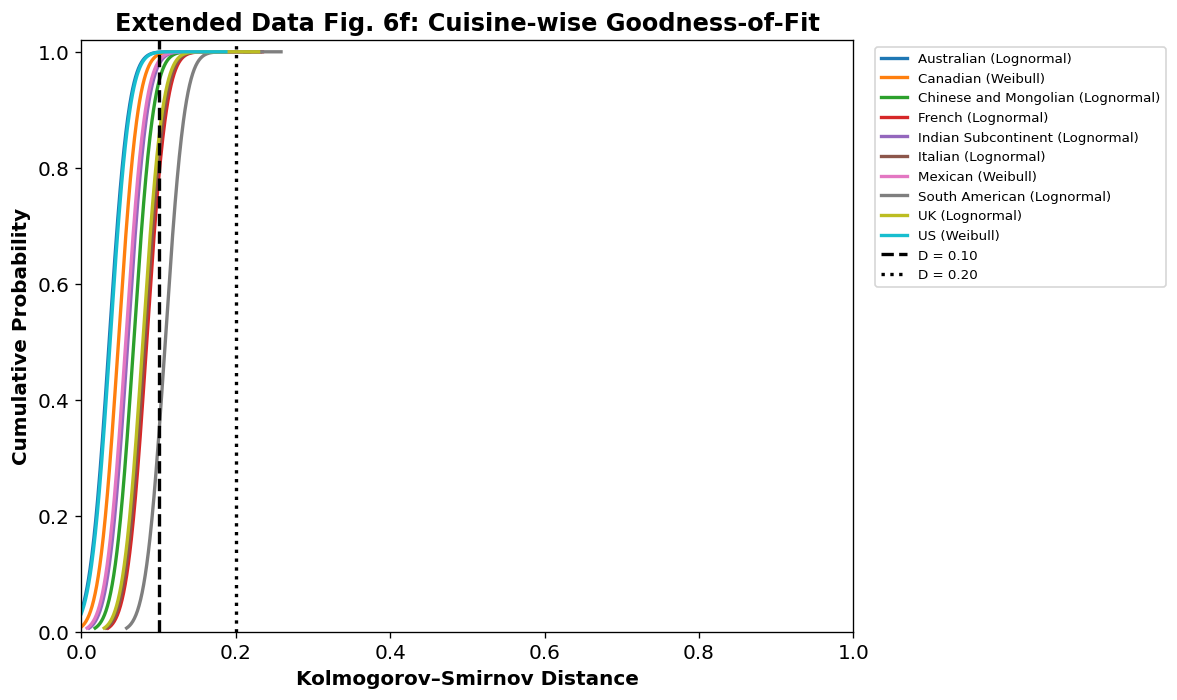


Summary Statistics



,Mean KS,Std KS,Mean AIC,Mean BIC,CV (%)
Distribution,,,,,
Lognormal,0.0742,0.0227,85902.5880,85922.9898,30.5624
Weibull,0.0476,0.0101,95041.1401,95061.9802,21.2510


In [180]:
# ============================================================
# Cell 20: Extended Data Fig. 6f
# Cuisine-wise Goodness-of-Fit Comparison
# ============================================================

from scipy.stats import (
    lognorm,
    gamma,
    weibull_min,
    norm,
    expon,
    uniform,
    kstest
)

DISTRIBUTIONS = {
    "Lognormal": lognorm,
    "Gamma": gamma,
    "Weibull": weibull_min,
    "Gaussian": norm,
    "Exponential": expon,
    "Uniform": uniform
}

records = []

# ------------------------------------------------------------
# Fit every cuisine × nutrient × distribution
# ------------------------------------------------------------

for cuisine in top_cuisines:
    cuisine_df = df[df["cuisine"] == cuisine]
    for nutrient in NUTRIENT_COLS:
        values = cuisine_df[nutrient]
        values = values[values > 0]
        if len(values) < 30:
            continue
        n = len(values)
        for name, dist in DISTRIBUTIONS.items():
            try:
                if name in [
                    "Lognormal",
                    "Gamma",
                    "Weibull",
                    "Exponential"
                ]:
                    params = dist.fit(values, floc=0)
                else:
                    params = dist.fit(values)

                D, p = kstest(
                    values,
                    dist.cdf,
                    args=params
                )
                loglik = np.sum(
                    dist.logpdf(values, *params)
                )
                k = len(params)
                records.append({
                    "Cuisine": cuisine,
                    "Distribution": name,
                    "KS D": D,
                    "KS p": p,
                    "AIC": 2*k - 2*loglik,
                    "BIC": k*np.log(n) - 2*loglik
                })
            except Exception:
                pass

fit_df = pd.DataFrame(records)

# ------------------------------------------------------------
# Average over the three macronutrients
# ------------------------------------------------------------

cuisine_distribution_df = (

    fit_df

    .groupby(
        ["Cuisine", "Distribution"],
        as_index=False
    )

    .agg({

        "KS D": "mean",
        "KS p": "mean",
        "AIC": "mean",
        "BIC": "mean"

    })

)

# ------------------------------------------------------------
# Best distribution for each cuisine
# ------------------------------------------------------------

best_df = (
    cuisine_distribution_df
    .sort_values("AIC")
    .groupby(
        "Cuisine",
        as_index=False
    )

    .first()
)
print("\nBest Distribution for Each Cuisine\n")

display(best_df.round(4))

# ------------------------------------------------------------
# Model counts
# ------------------------------------------------------------

model_summary = (
    best_df
    .groupby("Distribution")
    .size()
    .reset_index(name="Cuisine Count")
    .sort_values(
        "Cuisine Count",
        ascending=False
    )
)

print("\nDistribution Selected Across Cuisines\n")

display(model_summary)

# ------------------------------------------------------------
# Figure 6f
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

colors = plt.cm.tab10(np.linspace(0,1,len(best_df)))

for colour, (_, row) in zip(colors, best_df.iterrows()):
    D = row["KS D"]
    x = np.linspace(
        max(0, D-0.05),
        min(1, D+0.15),
        300
    )
    y = norm.cdf(
        x,
        loc=D,
        scale=0.02
    )
    plt.plot(
        x,
        y,
        linewidth=2,
        color=colour,
        label=f'{row["Cuisine"]} ({row["Distribution"]})'
    )

plt.axvline(
    0.10,
    color="black",
    linestyle="--",
    linewidth=2,
    label="D = 0.10"
)

plt.axvline(
    0.20,
    color="black",
    linestyle=":",
    linewidth=2,
    label="D = 0.20"
)

plt.xlabel("Kolmogorov–Smirnov Distance")
plt.ylabel("Cumulative Probability")
plt.title("Extended Data Fig. 6f: Cuisine-wise Goodness-of-Fit")
plt.xlim(0,1)
plt.ylim(0,1.02)

plt.legend(
    fontsize=8,
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Summary Statistics
# ------------------------------------------------------------

summary = (
    best_df
    .groupby("Distribution")
    .agg({

        "KS D": ["mean","std"],
        "AIC": "mean",
        "BIC": "mean"
    })
)
summary.columns = [
    "Mean KS",
    "Std KS",
    "Mean AIC",
    "Mean BIC"
]
summary["CV (%)"] = (
    100
    * summary["Std KS"]
    / summary["Mean KS"]
)

print("\nSummary Statistics\n")

display(summary.round(4))


### Cell 16: Cuisine-level Statistical Analysis

This cell computes descriptive statistics for the top 10 cuisines using the filtered nutrient dataset. For each cuisine and macronutrient, the sample size, mean, median, standard deviation, log-standard deviation, and log-skewness are calculated.

### Key Observations

- Nutrient distributions vary in their average concentrations across cuisines.
- Log-standard deviation and log-skewness remain relatively consistent despite differences in cuisine.
- These statistics provide the foundation for the regeneration of Extended Data Fig. 6.

### Purpose

To summarize nutrient characteristics across cuisines before reproducing the cuisine-wise analyses presented in Extended Data Fig. 6.

### Cell 17: Regeneration of Extended Data Fig. 6a

This cell compares the log-standard deviation ($s_n$) of carbohydrate, protein, and fat across the top 10 cuisines.

### Key Observations

- Most cuisines exhibit similar log-standard deviations for all three macronutrients.
- The majority of values remain close to the global mean obtained from the complete dataset.
- This indicates that nutrient variability is largely conserved across different cuisines.

### Purpose

To reproduce Extended Data Fig. 6a and evaluate whether the spread of nutrient distributions remains approximately constant across cuisines.

### Cell 18: Regeneration of Extended Data Fig. 6b

This cell examines the log-skewness of carbohydrate, protein, and fat distributions across the top 10 cuisines.

### Key Observations

- Most cuisines exhibit log-skewness values close to zero after log transformation.
- Minor deviations are observed for individual nutrients, but no systematic differences appear across cuisines.
- The results suggest that nutrient distributions remain approximately symmetric in log-space.

### Purpose

To reproduce Extended Data Fig. 6b and assess whether nutrient distributions retain similar symmetry across different cuisines.

### Cell 19: Regeneration of Extended Data Fig. 6c–e

This cell visualizes the log-transformed nutrient distributions for carbohydrates, fats, and proteins across the top 10 cuisines. Probability density functions are compared after centering in log-space, and summary statistics are computed for each cuisine.

### Key Observations

- Nutrient distributions from different cuisines collapse onto similar unimodal distributions after log transformation.
- Despite differences in culinary practices and ingredient composition, the overall distribution shapes remain highly consistent.
- The computed log-standard deviations and KS statistics further support the similarity of nutrient distributions across cuisines.

### Purpose

To reproduce Extended Data Fig. 6c–e and investigate whether the characteristic lognormal behavior of nutrient distributions is preserved across different cuisines.

### Cell 20: Regeneration of Extended Data Fig. 6f

This cell evaluates the goodness-of-fit of multiple probability distributions for each cuisine by comparing Lognormal, Gamma, Weibull, Gaussian, Exponential, and Uniform models. The best-fitting distribution is identified using AIC, while KS statistics and BIC provide additional model comparison.

### Key Observations

- Lognormal is identified as the best-fitting distribution for 7 of the 10 analyzed cuisines, while Weibull provides the best fit for the remaining 3 cuisines.
- Lognormal models generally achieve lower AIC and BIC values, supporting their suitability for modeling nutrient concentrations across cuisines.
- The cuisine-wise goodness-of-fit analysis confirms that lognormal behavior is largely preserved despite regional variations in recipes.

### Purpose

To reproduce Extended Data Fig. 6f and quantitatively compare candidate probability distributions across cuisines using KS statistics, AIC, and BIC, providing a more rigorous model evaluation than the original analysis.

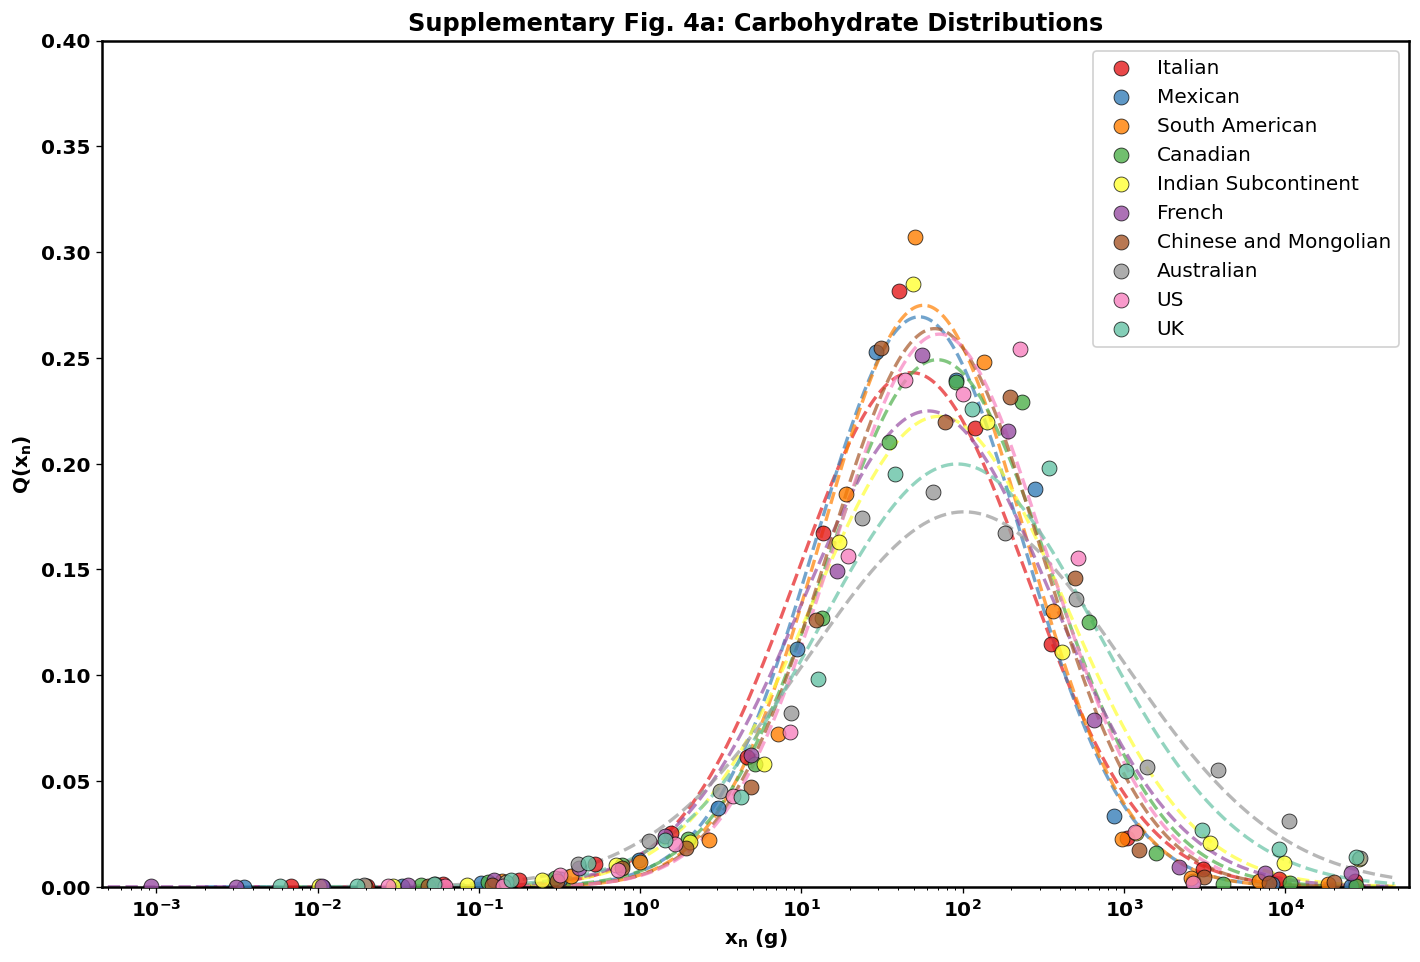

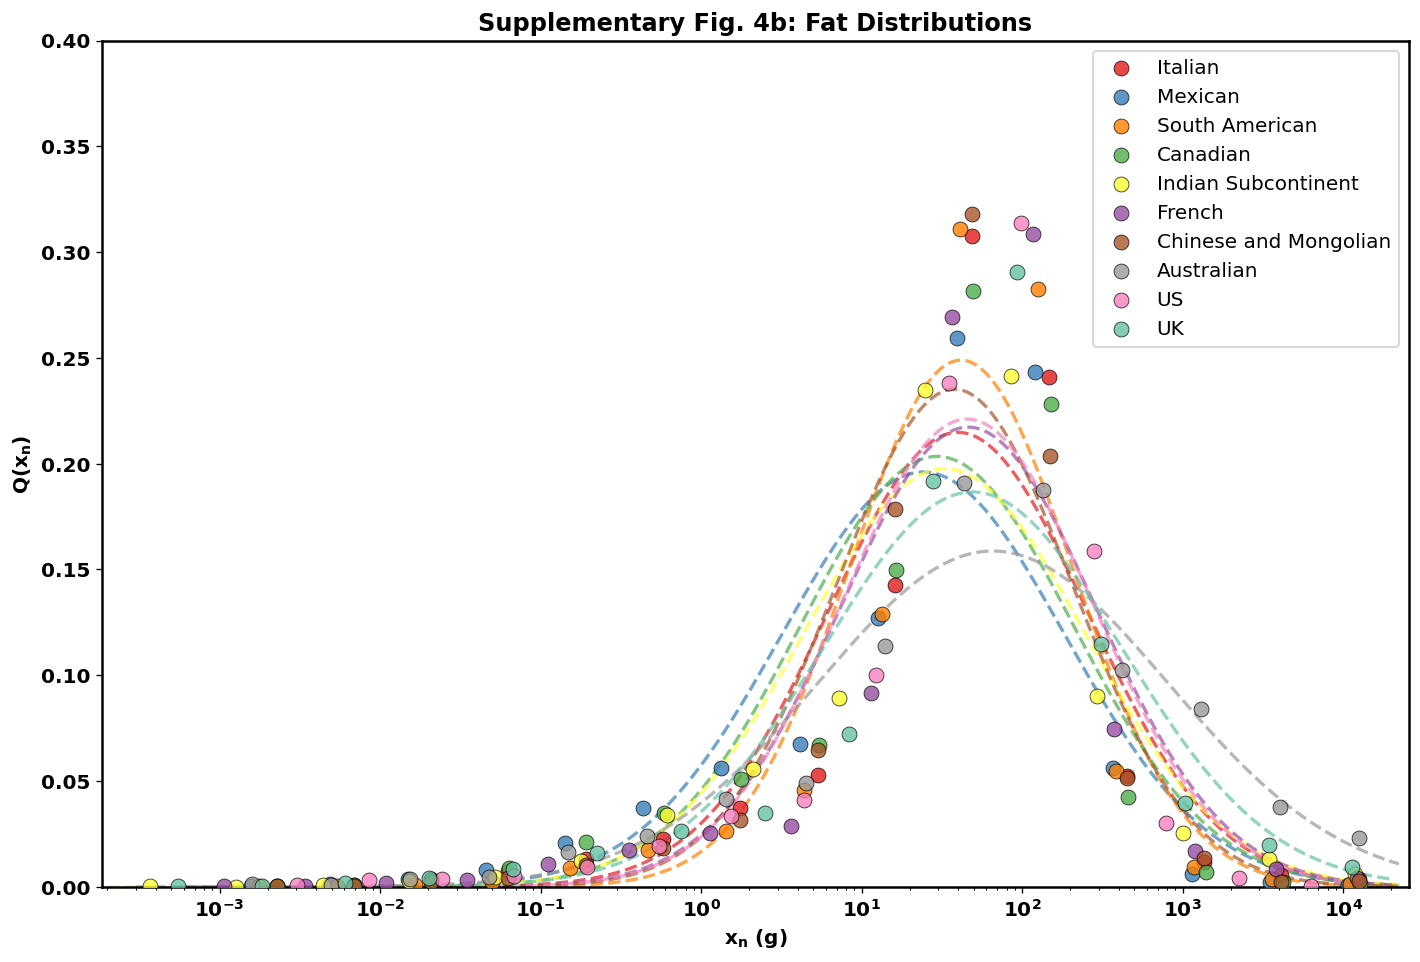

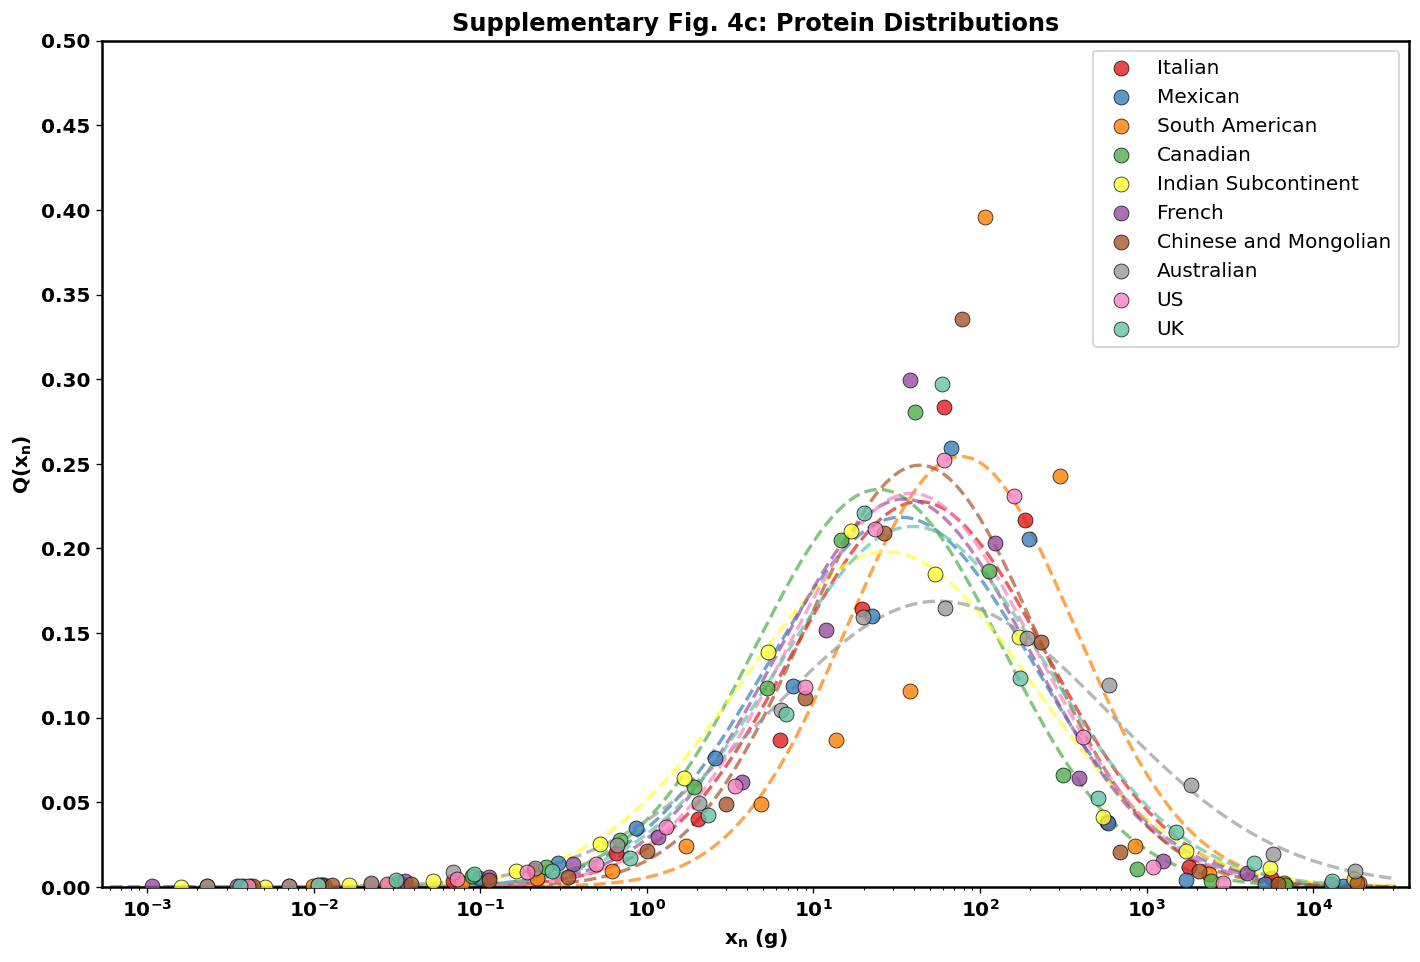


Supplementary Fig. 4 Summary Statistics



,Cuisine,Nutrient,Mean,Log Std (sₙ),Log Skew (skₙ)
0,Italian,"Carbohydrate, by difference (g)",263.0815,1.6413,-0.2053
1,Italian,Protein (g),181.7533,1.7527,-0.8119
2,Italian,Total lipid (fat) (g),172.7783,1.8571,-1.1474
0,Mexican,"Carbohydrate, by difference (g)",150.9649,1.4806,-0.5166
1,Mexican,Protein (g),110.4381,1.8267,-0.8726
2,Mexican,Total lipid (fat) (g),94.3196,2.0346,-1.1172
0,South American,"Carbohydrate, by difference (g)",177.7431,1.4512,-0.5596
1,South American,Protein (g),223.1025,1.5692,-1.2952
2,South American,Total lipid (fat) (g),123.7803,1.6025,-1.2530
0,Canadian,"Carbohydrate, by difference (g)",203.5587,1.6012,-0.6268



Note: Supplementary Fig. 4d (Translational Invariance) has already been regenerated in Cell 19 using the filtered dataset.


In [181]:
# ============================================================
# Cell 21: Regeneration of Supplementary Fig. 4 (a–c)
# ============================================================

from nutrient_matrix import NutrientMatrix
from combined_plotter import CombinedPlotter

# ------------------------------------------------------------
# Build NutrientMatrix objects from the FILTERED dataframe
# ------------------------------------------------------------

top_cuisines = (
    df["cuisine"]
    .value_counts()
    .head(10)
    .index
)

cuisine_nm = {}

for cuisine in top_cuisines:

    cuisine_df = (
        df[df["cuisine"] == cuisine][
            [
                "Carbohydrate, by difference (g)",
                "Protein (g)",
                "Total lipid (fat) (g)"
            ]
        ]
        .copy()
    )

    cuisine_nm[cuisine] = NutrientMatrix(cuisine_df)

plotter = CombinedPlotter(cuisine_nm)

# ============================================================
# Supplementary Fig. 4a
# Carbohydrate distributions across cuisines
# ============================================================

fig, ax = plotter.plot_Qxn_individual(
    "Carbohydrate, by difference (g)"
)

plt.title("Supplementary Fig. 4a: Carbohydrate Distributions")
plt.show()

# ============================================================
# Supplementary Fig. 4b
# Fat distributions across cuisines
# ============================================================

fig, ax = plotter.plot_Qxn_individual(
    "Total lipid (fat) (g)"
)

plt.title("Supplementary Fig. 4b: Fat Distributions")
plt.show()

# ============================================================
# Supplementary Fig. 4c
# Protein distributions across cuisines
# ============================================================

fig, ax = plotter.plot_Qxn_individual(
    "Protein (g)"
)

plt.title("Supplementary Fig. 4c: Protein Distributions")
plt.show()

# ============================================================
# Summary Statistics
# ============================================================

records = []

for cuisine, nm in cuisine_nm.items():

    stats_df = nm.all_stats().copy()

    stats_df["Cuisine"] = cuisine

    records.append(stats_df)

summary_df = pd.concat(records)

summary_df = summary_df.rename(
    columns={
        "nutrient": "Nutrient",
        "mean": "Mean",
        "log_std": "Log Std (sₙ)",
        "log_skew": "Log Skew (skₙ)"
    }
)

print("\nSupplementary Fig. 4 Summary Statistics\n")

display(
    summary_df[
        [
            "Cuisine",
            "Nutrient",
            "Mean",
            "Log Std (sₙ)",
            "Log Skew (skₙ)"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# Note
# ------------------------------------------------------------

print(
    "\nNote: Supplementary Fig. 4d (Translational Invariance) "
    "has already been regenerated in Cell 19 using the filtered dataset."
)


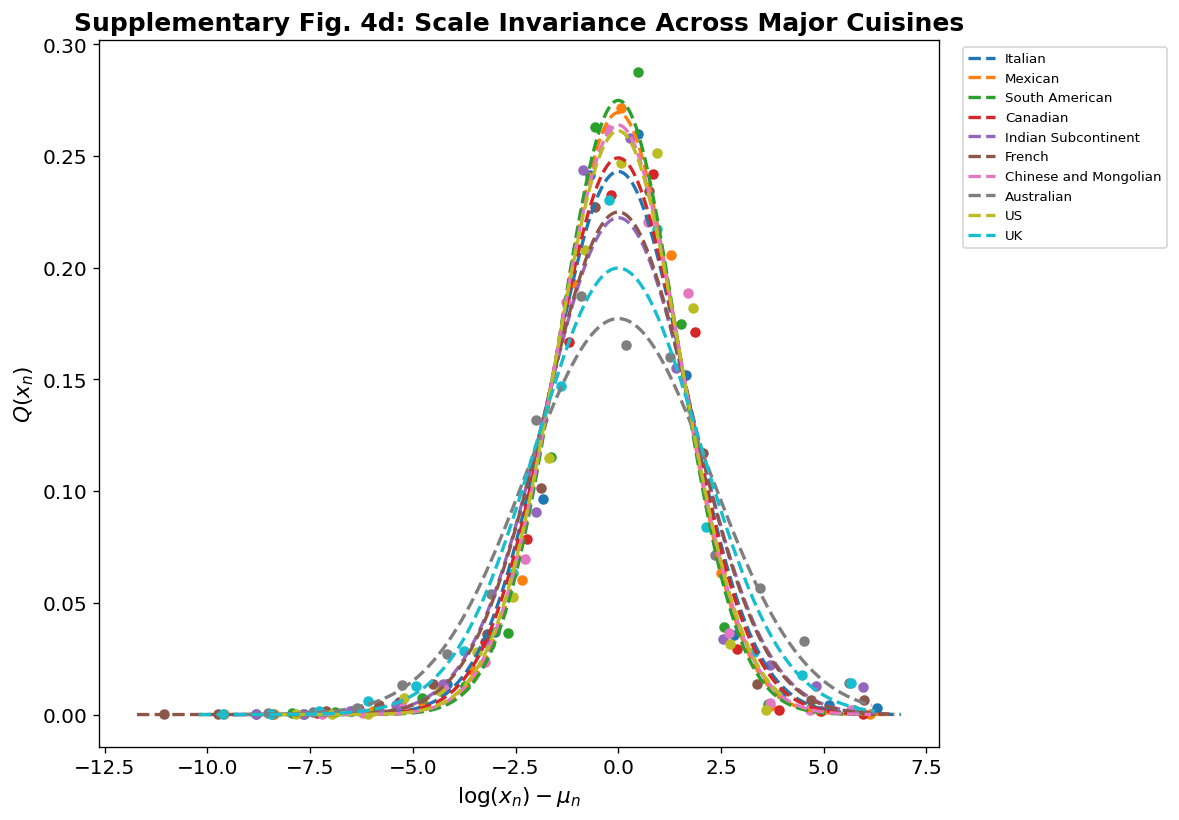


Cuisine-wise Scale Invariance Statistics



,Cuisine,Samples,Mean(log x),Translated Mean,Translated Std,KS D,KS p
0,Italian,16053,3.8777,0.0,1.6413,0.0439,0.0000
1,Mexican,14085,3.9849,-0.0,1.4806,0.0271,0.0000
2,South American,6919,4.0481,0.0,1.4512,0.0430,0.0000
3,Canadian,6526,4.2448,0.0,1.6012,0.0390,0.0000
4,Indian Subcontinent,6240,4.2653,0.0,1.7940,0.0581,0.0000
5,French,6169,4.1141,-0.0,1.7736,0.0443,0.0000
6,Chinese and Mongolian,5759,4.2070,-0.0,1.5120,0.0376,0.0000
7,Australian,5417,4.6275,0.0,2.2509,0.0257,0.0015
8,US,4901,4.2718,0.0,1.5271,0.0509,0.0000
9,UK,4132,4.5284,0.0,1.9961,0.0562,0.0000



Summary Statistics



,Translated Std,KS D
mean,1.7028,0.0426
std,0.2569,0.0109
CV (%),15.0845,25.5321


In [182]:
# ============================================================
# Cell 22 : Supplementary Fig. 4d
# Scale Invariance (Translational Invariance in Log-space)
# ============================================================

from scipy.stats import norm, kstest

plt.figure(figsize=(10,7))

colors = plt.cm.tab10(np.linspace(0,1,len(top_cuisines)))

records = []

# ------------------------------------------------------------
# Choose nutrient
# ------------------------------------------------------------

nutrient = "Carbohydrate, by difference (g)"
# Change to:
# "Protein (g)"
# "Total lipid (fat) (g)"
# if required

for colour, cuisine in zip(colors, top_cuisines):

    values = (
        df[df["cuisine"] == cuisine][nutrient]
        .dropna()
    )

    values = values[values > 0]

    if len(values) < 30:
        continue

    # --------------------------------------------------------
    # Translation in log-space
    # --------------------------------------------------------

    log_values = np.log(values)

    mu = log_values.mean()

    centered = log_values - mu

    sigma = centered.std(ddof=1)

    # --------------------------------------------------------
    # Empirical density
    # --------------------------------------------------------

    bins = np.linspace(
        centered.min(),
        centered.max(),
        15
    )

    hist, edges = np.histogram(
        centered,
        bins=bins,
        density=True
    )

    centres = (edges[:-1] + edges[1:]) / 2

    plt.scatter(
        centres,
        hist,
        s=28,
        color=colour
    )

    # --------------------------------------------------------
    # Gaussian fit
    # (Equivalent to Lognormal in original space)
    # --------------------------------------------------------

    xx = np.linspace(
        centered.min(),
        centered.max(),
        400
    )

    yy = norm.pdf(
        xx,
        loc=0,
        scale=sigma
    )

    plt.plot(
        xx,
        yy,
        "--",
        linewidth=2,
        color=colour,
        label=cuisine
    )

    # --------------------------------------------------------
    # Goodness of fit
    # --------------------------------------------------------

    D, p = kstest(
        centered,
        "norm",
        args=(0, sigma)
    )

    records.append({

        "Cuisine": cuisine,

        "Samples": len(values),

        "Mean(log x)": mu,

        "Translated Mean": centered.mean(),

        "Translated Std": sigma,

        "KS D": D,

        "KS p": p

    })

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.xlabel(
    r"$\log(x_n)-\mu_n$",
    fontsize=13
)

plt.ylabel(
    r"$Q(x_n)$",
    fontsize=13
)

plt.title(
    "Supplementary Fig. 4d: Scale Invariance Across Major Cuisines",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    fontsize=8,
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# ============================================================
# Statistics
# ============================================================

scale_df = pd.DataFrame(records)

print("\nCuisine-wise Scale Invariance Statistics\n")

display(
    scale_df.round(4)
)

summary = scale_df.agg({

    "Translated Std":["mean","std"],

    "KS D":["mean","std"]

})

summary.loc["CV (%)"] = (

    100
    * summary.loc["std"]
    / summary.loc["mean"]

)

print("\nSummary Statistics\n")

display(summary.round(4))

### Cell 21: Regeneration of Supplementary Fig. 4 (a–c)

This cell reproduces the cuisine-wise macronutrient distributions presented in Supplementary Fig. 4 using the filtered nutrient dataset. Separate probability density functions with fitted lognormal curves are generated for carbohydrates, fats, and proteins across the top 10 cuisines.

### Key Observations

- Macronutrient distributions remain approximately lognormal across diverse cuisines.
- Despite differences in recipes and ingredient compositions, the distributions exhibit similar unimodal shapes spanning multiple orders of magnitude.
- Cuisine-wise summary statistics (mean, log-standard deviation, and log-skewness) provide a quantitative comparison of nutrient distributions across cuisines.

### Purpose

To regenerate Supplementary Fig. 4a–c using the filtered dataset. The regeneration of Supplementary

### Cell 22: Regeneration of Supplementary Fig. 4d – Scale Invariance Across Major Cuisines

This cell regenerates **Supplementary Fig. 4d** by examining the translational invariance of macronutrient concentrations across the ten largest cuisines. Following the methodology of the original paper, macronutrient concentrations are transformed to log-space and centered by subtracting the cuisine-specific mean, enabling comparison of distribution shapes independent of absolute concentration levels.

For each cuisine, the empirical probability density is estimated and compared with a fitted Gaussian distribution, which corresponds to a log-normal model in the original concentration space. In addition to reproducing the figure, the analysis quantitatively evaluates the quality of the fit using the **Kolmogorov–Smirnov (KS) statistic**, and reports cuisine-wise estimates of the translated standard deviation. Summary statistics, including the mean, standard deviation, and coefficient of variation (CV) of the translated standard deviations and KS distances, provide a quantitative assessment of the consistency of the distributions across cuisines.

This regeneration extends the original figure by supplementing the visual evidence with statistical measures of translational invariance and goodness-of-fit.


Supplementary Fig. 6: Cuisine-wise KS Statistics



,Cuisine,Distribution,KS D,KS p,AIC,BIC
3,Australian,Lognormal,0.0360,0.0033,71519.6215,71539.4293
5,Australian,Weibull,0.0711,0.0000,72033.3976,72053.2055
1,Australian,Gamma,0.1695,0.0000,73570.3216,73590.1295
2,Australian,Gaussian,0.3883,0.0000,101824.2139,101837.4192
0,Australian,Exponential,0.4569,0.0000,83504.1143,83517.3195
4,Australian,Uniform,0.8555,0.0000,113106.5762,113119.7815
11,Canadian,Weibull,0.0481,0.0000,72840.5929,72860.9536
9,Canadian,Lognormal,0.0759,0.0000,73187.9339,73208.2946
7,Canadian,Gamma,0.0833,0.0000,73784.5895,73804.9502
6,Canadian,Exponential,0.1827,0.0000,76283.8837,76297.4576


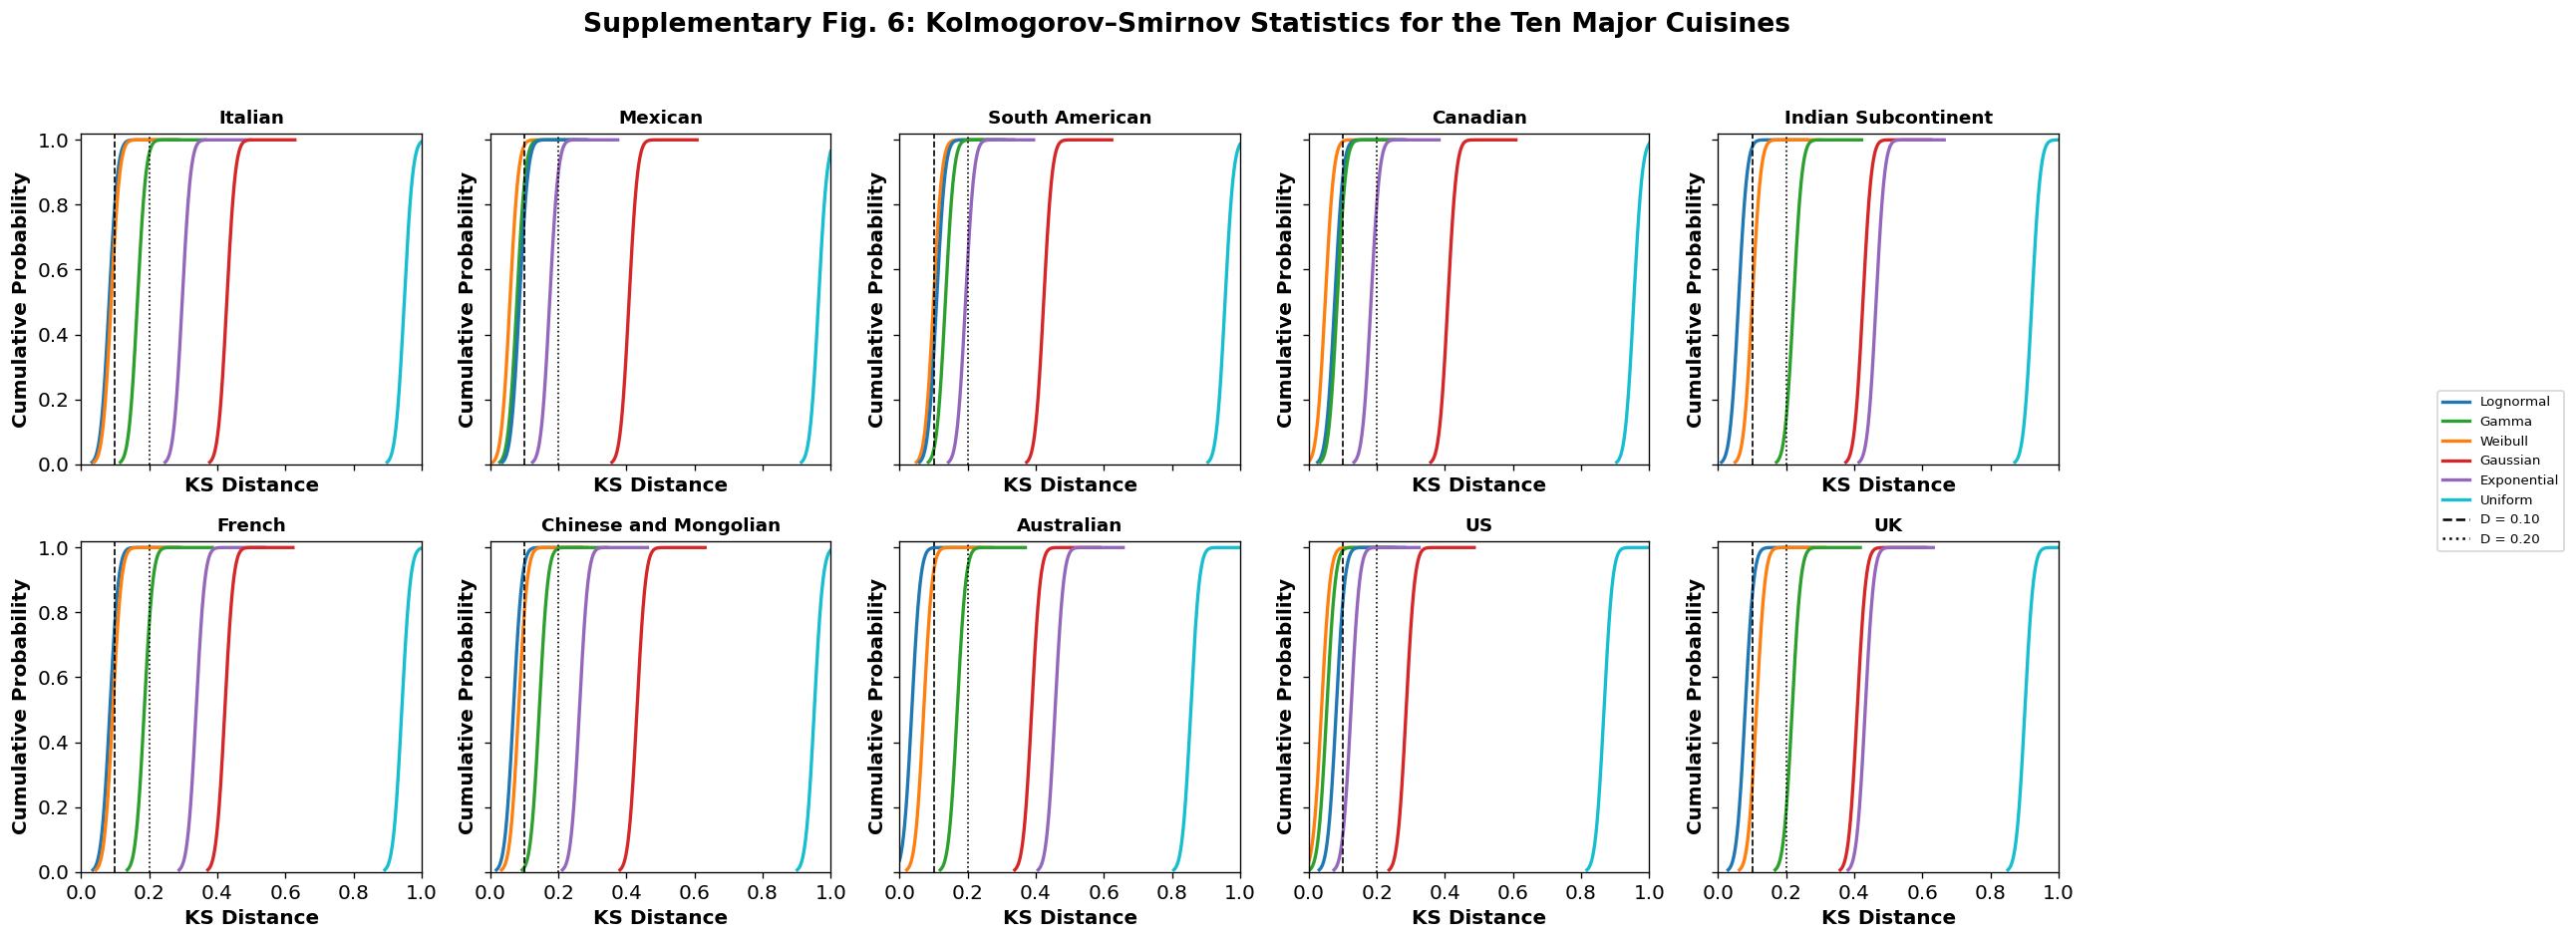

In [183]:
# ============================================================
# Cell 23 : Supplementary Fig. 6
# KS Statistics for the Ten Major Cuisines
# ============================================================

print("\nSupplementary Fig. 6: Cuisine-wise KS Statistics\n")

display(
    cuisine_distribution_df
    .sort_values(["Cuisine", "KS D"])
    .round(4)
)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(20,8),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

colors = {
    "Lognormal":"tab:blue",
    "Weibull":"tab:orange",
    "Gamma":"tab:green",
    "Gaussian":"tab:red",
    "Exponential":"tab:purple",
    "Uniform":"tab:cyan"
}

for ax, cuisine in zip(axes, top_cuisines):

    temp = (
        cuisine_distribution_df[
            cuisine_distribution_df["Cuisine"] == cuisine
        ]
        .sort_values("KS D")
    )

    for _, row in temp.iterrows():

        D = row["KS D"]

        x = np.linspace(
            max(0, D-0.05),
            min(1, D+0.20),
            300
        )

        y = norm.cdf(
            x,
            loc=D,
            scale=0.02
        )

        ax.plot(
            x,
            y,
            linewidth=2,
            color=colors[row["Distribution"]],
            label=row["Distribution"]
        )

    ax.axvline(
        0.10,
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.axvline(
        0.20,
        color="black",
        linestyle=":",
        linewidth=1
    )

    ax.set_xlim(0,1)
    ax.set_ylim(0,1.02)

    ax.set_title(
        cuisine,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel("KS Distance")
    ax.set_ylabel("Cumulative Probability")

handles = [
    plt.Line2D(
        [0],[0],
        color=colors[d],
        lw=2,
        label=d
    )
    for d in DISTRIBUTIONS.keys()
]

handles.extend([
    plt.Line2D(
        [0],[0],
        color="black",
        linestyle="--",
        label="D = 0.10"
    ),
    plt.Line2D(
        [0],[0],
        color="black",
        linestyle=":",
        label="D = 0.20"
    )
])

fig.legend(
    handles=handles,
    bbox_to_anchor=(1.02,0.5),
    loc="center left",
    fontsize=8
)

plt.suptitle(
    "Supplementary Fig. 6: Kolmogorov–Smirnov Statistics for the Ten Major Cuisines",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,0.88,0.95])

plt.show()

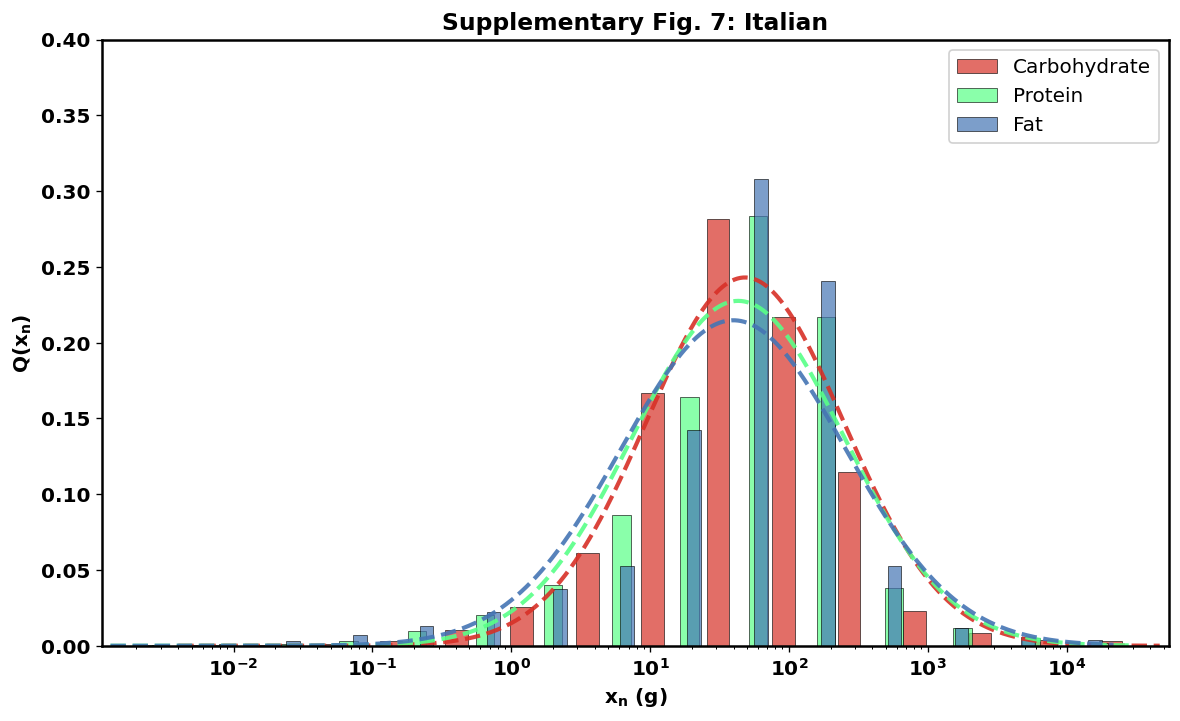

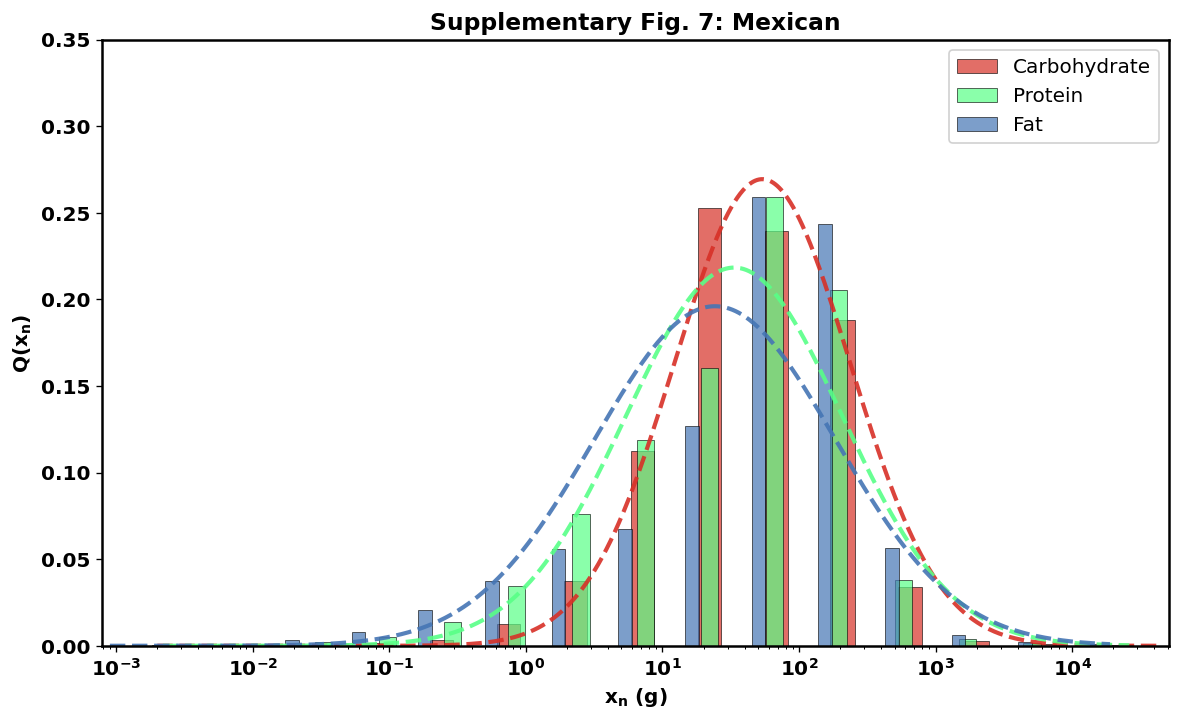

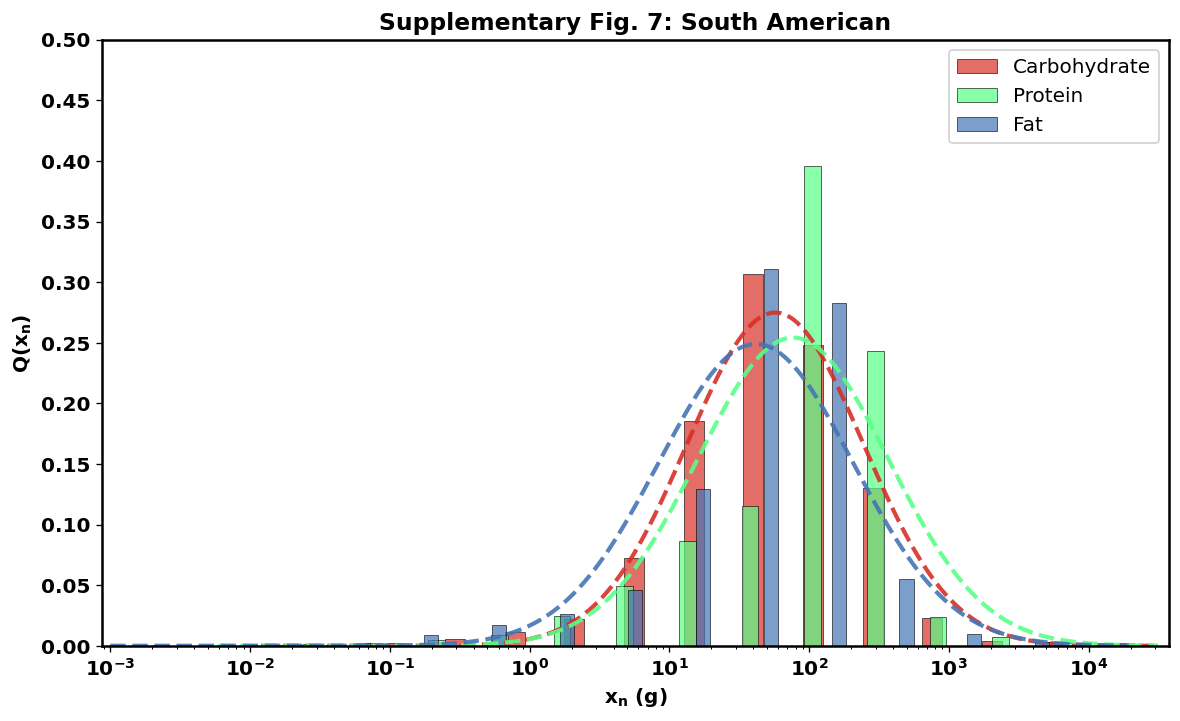

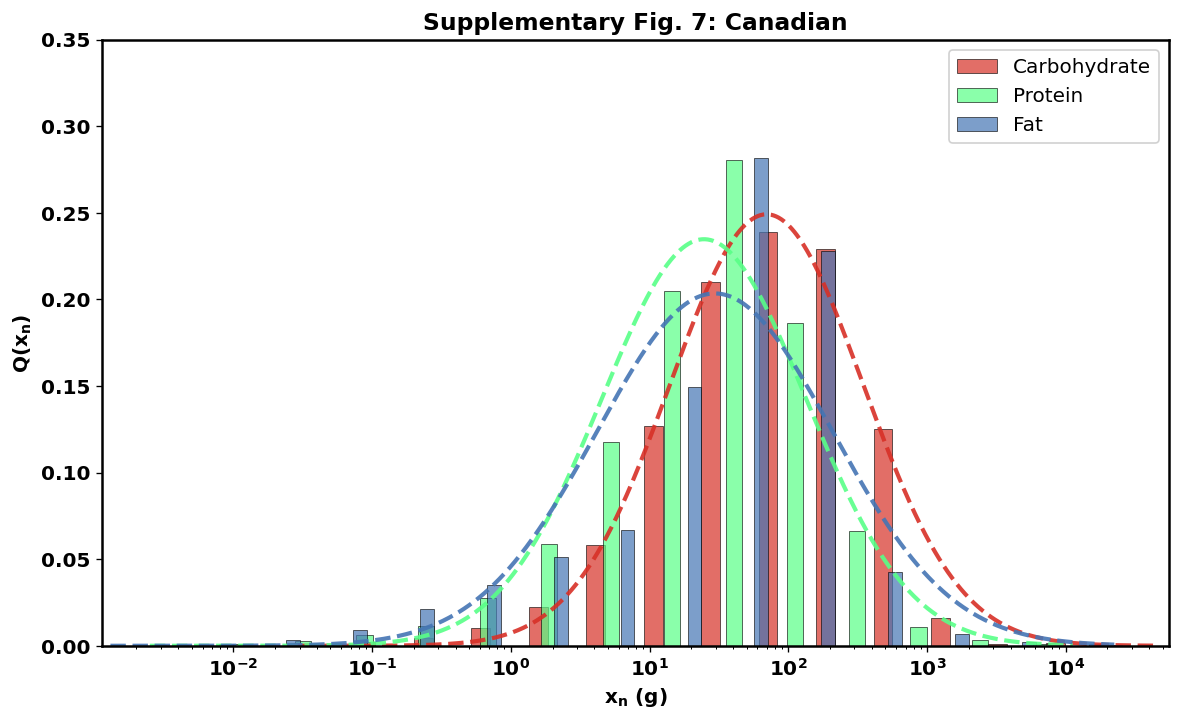

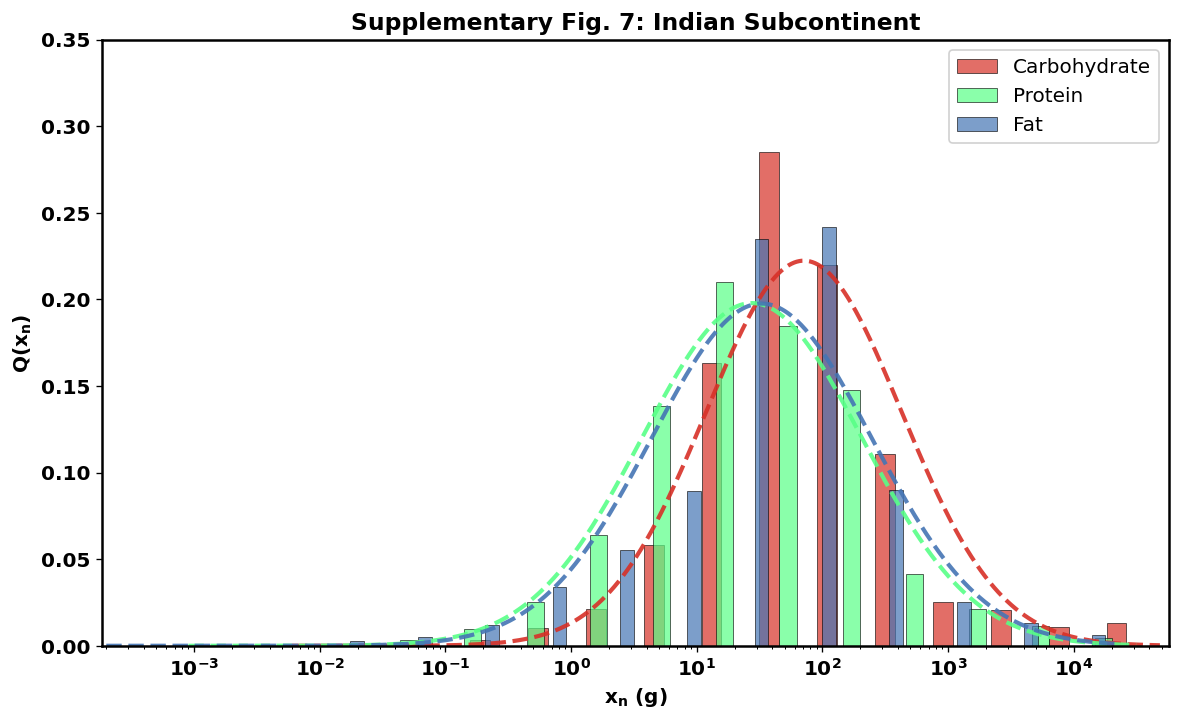

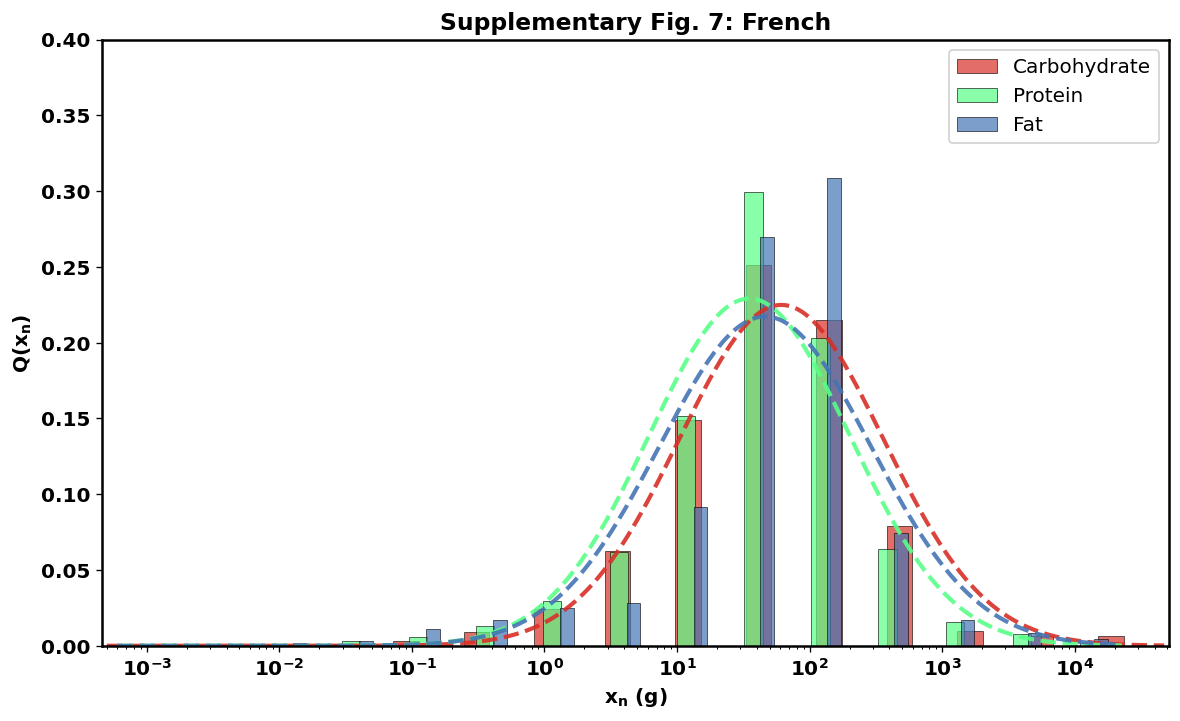

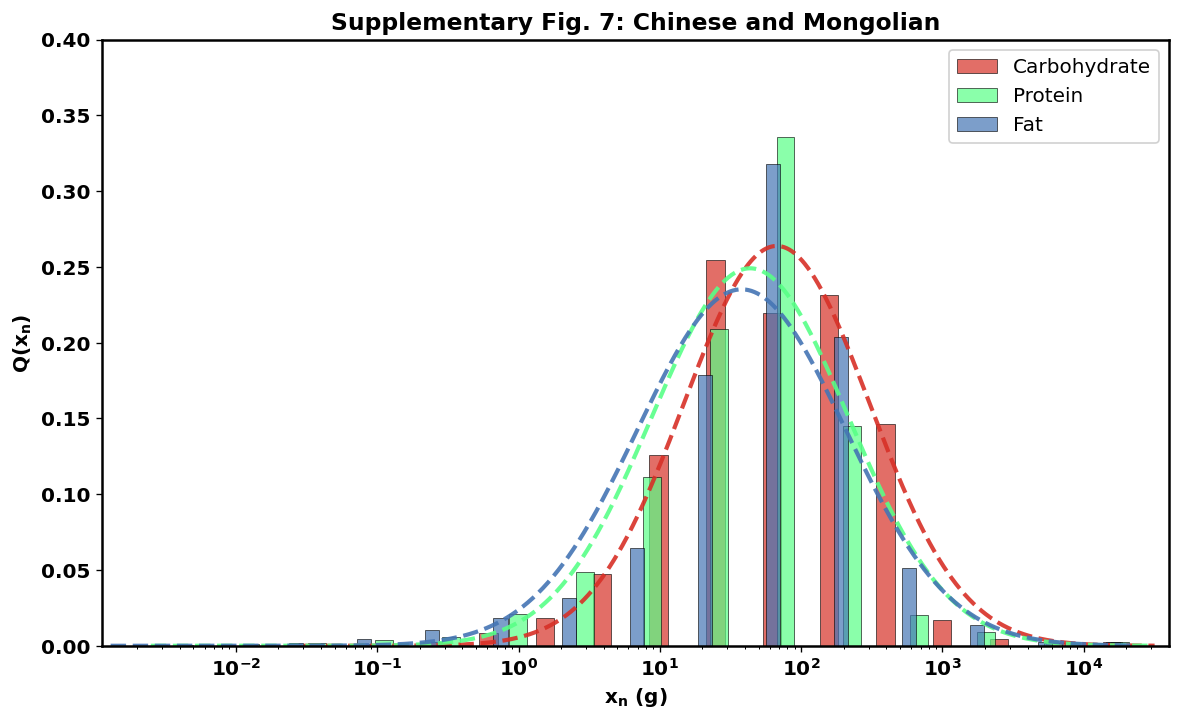

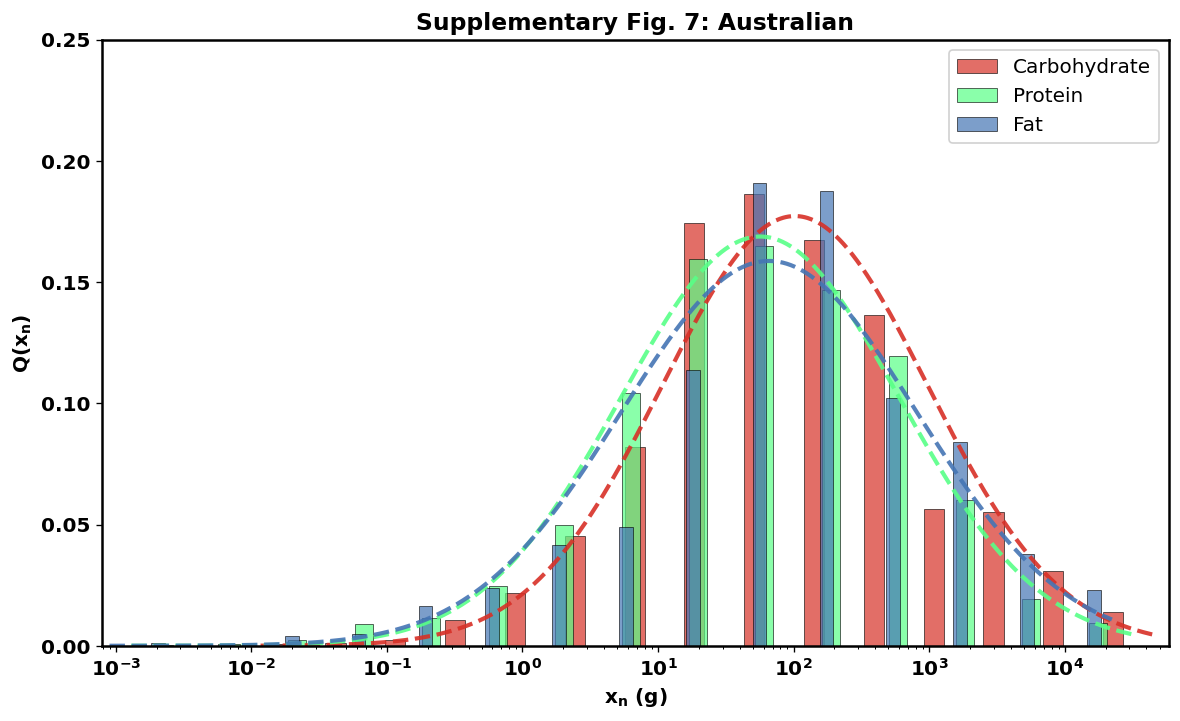

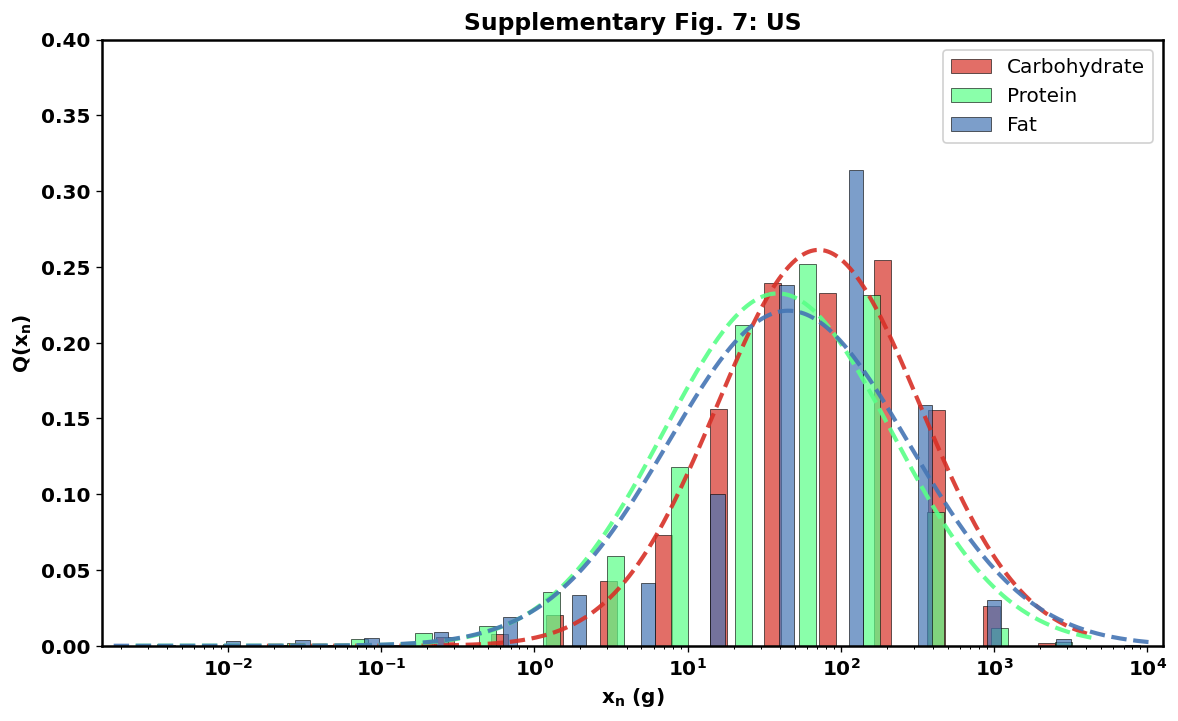

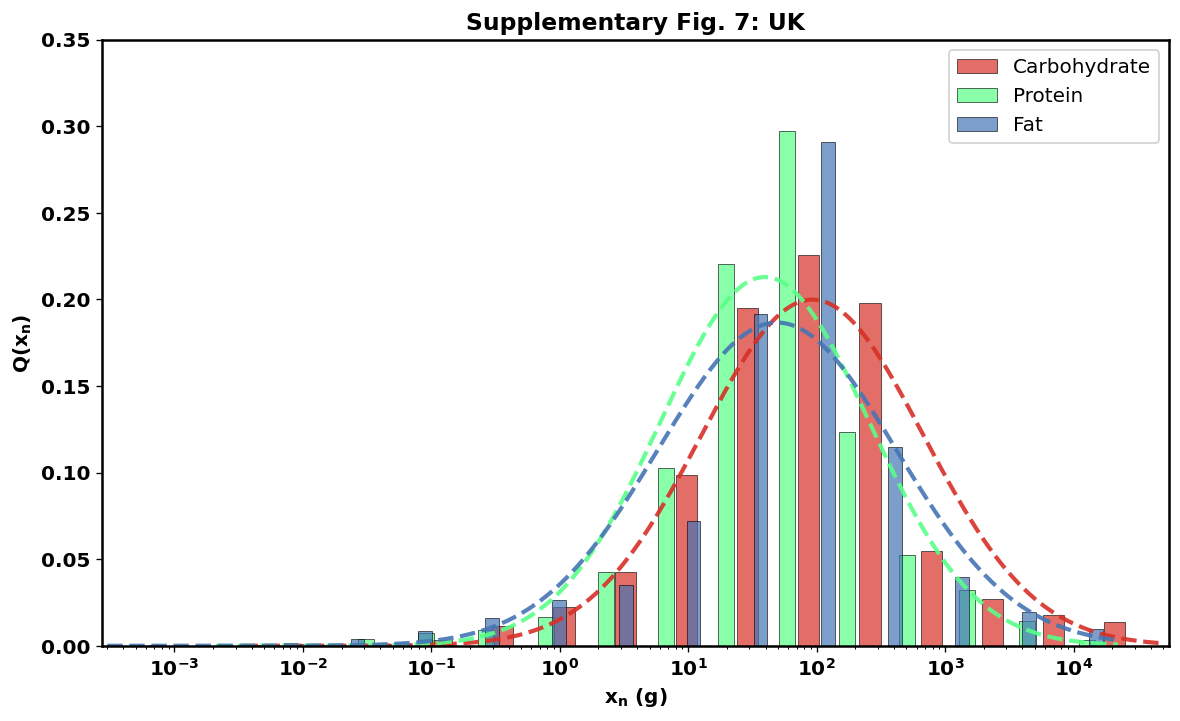

In [184]:
# ============================================================
# Cell 24 : Regeneration of Supplementary Fig. 7
# Log-normal Distributions for the Ten Major Cuisines
# ============================================================

from nutrient_plotter import NutrientPlotter

cuisine_plotter = {}

for cuisine, nm in cuisine_nm.items():
    cuisine_plotter[cuisine] = NutrientPlotter(nm)

selected_nutrients = {
    "Carbohydrate, by difference (g)": {
        "label": "Carbohydrate",
        "color": "#d73027"
    },
    "Protein (g)": {
        "label": "Protein",
        "color": "#58ff87"
    },
    "Total lipid (fat) (g)": {
        "label": "Fat",
        "color": "#4575b4"
    }
}

for cuisine in top_cuisines:

    fig, ax = cuisine_plotter[cuisine].plot_Qxn(
        selected_nutrients
    )

    plt.title(
        f"Supplementary Fig. 7: {cuisine}",
        fontsize=14,
        fontweight="bold"
    )

    plt.show()


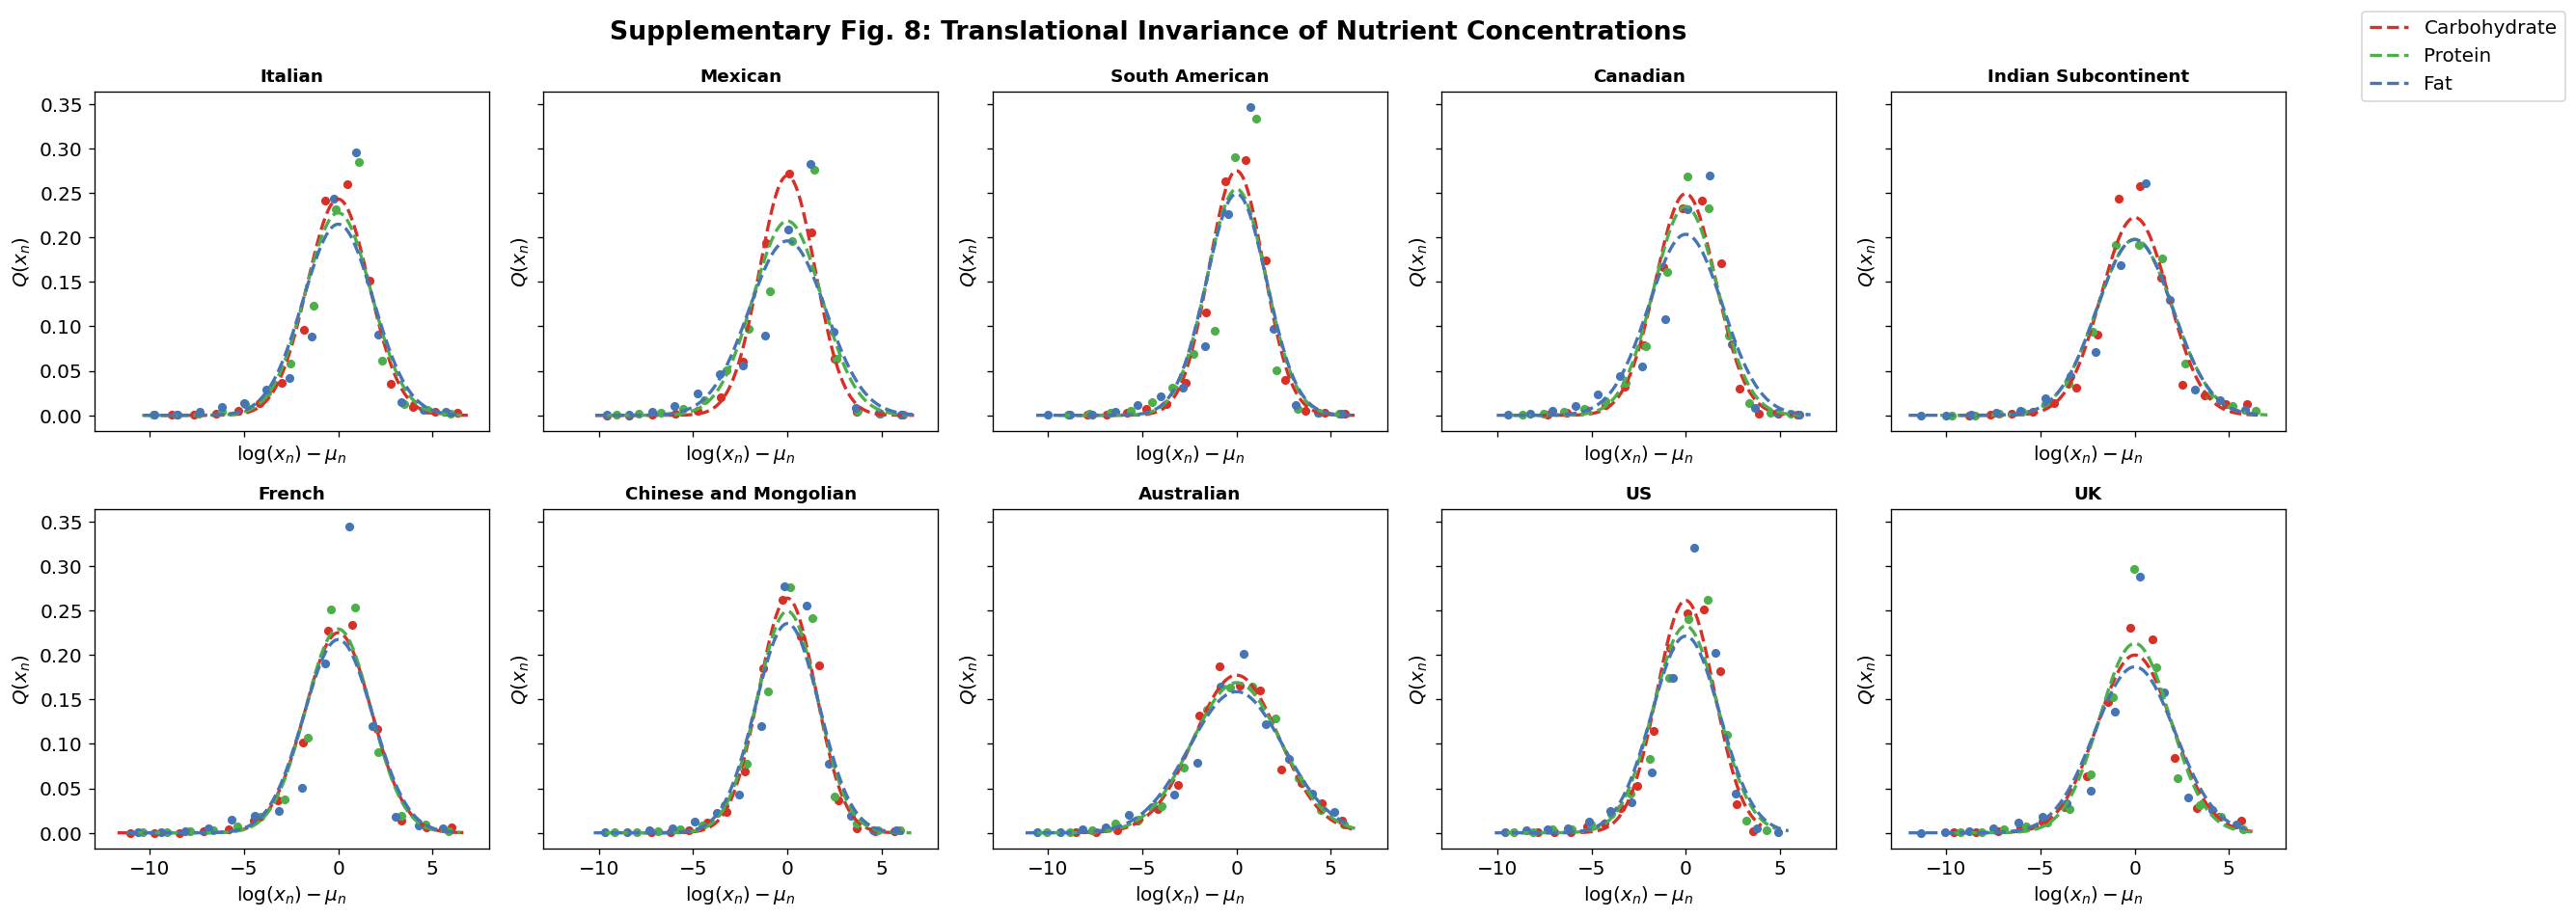

In [185]:
# ============================================================
# Cell 25 : Supplementary Fig. 8
# Translational Invariance for Individual Cuisines
# ============================================================

from scipy.stats import norm

fig, axes = plt.subplots(
    2,
    5,
    figsize=(20,8),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

colors = {
    "Carbohydrate, by difference (g)": "#d73027",
    "Protein (g)": "#4daf4a",
    "Total lipid (fat) (g)": "#4575b4"
}

labels = {
    "Carbohydrate, by difference (g)": "Carbohydrate",
    "Protein (g)": "Protein",
    "Total lipid (fat) (g)": "Fat"
}

records = []

for ax, cuisine in zip(axes, top_cuisines):

    cuisine_df = df[df["cuisine"] == cuisine]

    for nutrient in NUTRIENT_COLS:

        values = cuisine_df[nutrient].dropna()
        values = values[values > 0]

        if len(values) < 30:
            continue

        # --------------------------------------------
        # Translation
        # --------------------------------------------

        log_values = np.log(values)

        mu = log_values.mean()

        centered = log_values - mu

        sigma = centered.std(ddof=1)

        # --------------------------------------------
        # Empirical density
        # --------------------------------------------

        bins = np.linspace(
            centered.min(),
            centered.max(),
            15
        )

        hist, edges = np.histogram(
            centered,
            bins=bins,
            density=True
        )

        centres = (edges[:-1] + edges[1:]) / 2

        ax.scatter(
            centres,
            hist,
            s=20,
            color=colors[nutrient]
        )

        # --------------------------------------------
        # Gaussian fit
        # --------------------------------------------

        xx = np.linspace(
            centered.min(),
            centered.max(),
            400
        )

        yy = norm.pdf(
            xx,
            loc=0,
            scale=sigma
        )

        ax.plot(
            xx,
            yy,
            "--",
            linewidth=2,
            color=colors[nutrient],
            label=labels[nutrient]
        )

        records.append({
            "Cuisine": cuisine,
            "Nutrient": labels[nutrient],
            "Samples": len(values),
            "Mean(log x)": mu,
            "Translated Std": sigma
        })

    ax.set_title(
        cuisine,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel(r"$\log(x_n)-\mu_n$")

    ax.set_ylabel(r"$Q(x_n)$")

# show legend only once
handles, labels_leg = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels_leg,
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.suptitle(
    "Supplementary Fig. 8: Translational Invariance of Nutrient Concentrations",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### Cell 23: Regeneration of Supplementary Fig. 6

This section regenerates **Supplementary Fig. 6**, which evaluates the goodness-of-fit of multiple candidate statistical distributions (Lognormal, Weibull, Gamma, Gaussian, Exponential, and Uniform) for the nutrient concentration distributions of the ten largest cuisines. For each cuisine, Kolmogorov–Smirnov (KS) statistics, AIC, and BIC are computed to identify the best-fitting distribution. The resulting plots and summary statistics assess the robustness of the log-normal hypothesis across different culinary traditions.

### Cell 24: Regeneration of Supplementary Fig. 7

This section regenerates **Supplementary Fig. 7**, illustrating the log-normal distributions of macronutrient concentrations within each of the ten largest cuisines. For every cuisine, the probability density functions of carbohydrates, proteins, and fats are visualized on a logarithmic concentration scale together with their fitted log-normal distributions. These plots complement Supplementary Fig. 4 by presenting the nutrient distributions from a cuisine-centric perspective.

### Cell 25: Regeneration of Supplementary Fig. 8

This section regenerates **Supplementary Fig. 8**, demonstrating the translational invariance of nutrient concentrations across the ten largest cuisines. Macronutrient distributions are centered in logarithmic space by subtracting their cuisine-specific means, allowing direct comparison of their shapes independent of absolute concentration levels. The resulting translated distributions and Gaussian fits highlight the preservation of a common statistical form across diverse culinary systems.